In [ ]:
!pip install numpy pandas scikit-learn scipy requests -q
!pip install lime -q
!pip install tensorflow -q
!pip install scikit-surprise -q



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Setup & Imports

In [ ]:
# Dependency installation is in Cell 1 above.
# Run that cell first, restart the kernel, then run from here.


In [ ]:
# Core imports
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.linalg import svds
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings
import os
import zipfile
import urllib.request
import io

warnings.filterwarnings('ignore')
np.random.seed(42)
print('Core imports successful')

Core imports successful


## Data Loading

Download and load the MovieLens 100K dataset.

In [ ]:
# Download MovieLens 100K dataset
DATA_DIR = 'ml-100k'

if not os.path.exists(DATA_DIR):
    print('Downloading MovieLens 100K...')
    url = 'https://files.grouplens.org/datasets/movielens/ml-100k.zip'
    urllib.request.urlretrieve(url, 'ml-100k.zip')
    with zipfile.ZipFile('ml-100k.zip', 'r') as z:
        z.extractall('.')
    print('Downloaded and extracted successfully')
else:
    print('Dataset already present')

# ----- Load Ratings -----
rating_cols = ['user_id', 'movie_id', 'rating', 'timestamp']
ratings = pd.read_csv(f'{DATA_DIR}/u.data', sep='\t', names=rating_cols)

# ----- Load Movies -----
movie_cols = [
    'movie_id', 'title', 'release_date', 'video_release_date', 'imdb_url',
    'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]
movies = pd.read_csv(f'{DATA_DIR}/u.item', sep='|', names=movie_cols,
                     encoding='latin-1', usecols=range(24))

# ----- Load Users -----
user_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
users = pd.read_csv(f'{DATA_DIR}/u.user', sep='|', names=user_cols)

print(f'Ratings: {ratings.shape}  |  Movies: {movies.shape}  |  Users: {users.shape}')
print('\nRatings sample:')
ratings.head(3)

Dataset already present
Ratings: (100000, 4)  |  Movies: (1682, 24)  |  Users: (943, 5)

Ratings sample:


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


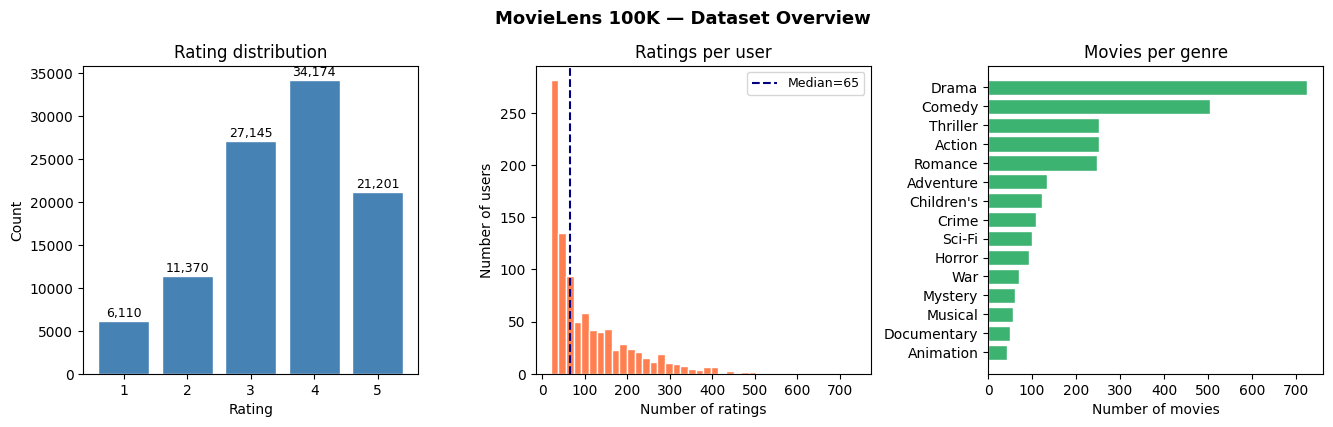

In [ ]:
# ── Visualization 1: Dataset Overview ──────────────────────────────────
!pip install seaborn -q
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Define here in case this cell runs before the genre setup cell
_GENRE_COLS = [
    'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

fig = plt.figure(figsize=(16, 4))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# 1a. Rating distribution
ax1 = fig.add_subplot(gs[0])
rating_counts = ratings['rating'].value_counts().sort_index()
ax1.bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='white')
ax1.set_title('Rating distribution', fontsize=12)
ax1.set_xlabel('Rating')
ax1.set_ylabel('Count')
for i_r, v in zip(rating_counts.index, rating_counts.values):
    ax1.text(i_r, v + 500, f'{v:,}', ha='center', fontsize=9)

# 1b. Ratings per user
ax2 = fig.add_subplot(gs[1])
ratings_per_user = ratings.groupby('user_id').size()
ax2.hist(ratings_per_user, bins=40, color='coral', edgecolor='white')
ax2.set_title('Ratings per user', fontsize=12)
ax2.set_xlabel('Number of ratings')
ax2.set_ylabel('Number of users')
ax2.axvline(ratings_per_user.median(), color='navy', linestyle='--',
            label=f'Median={ratings_per_user.median():.0f}')
ax2.legend(fontsize=9)

# 1c. Top 15 genres by movie count
ax3 = fig.add_subplot(gs[2])
genre_totals = movies[_GENRE_COLS].sum().sort_values(ascending=True).tail(15)
ax3.barh(genre_totals.index, genre_totals.values, color='mediumseagreen', edgecolor='white')
ax3.set_title('Movies per genre', fontsize=12)
ax3.set_xlabel('Number of movies')

plt.suptitle('MovieLens 100K — Dataset Overview', fontsize=13, fontweight='bold', y=1.02)
plt.savefig('viz1_dataset_overview.png', bbox_inches='tight', dpi=120)
plt.show()


In [ ]:
# Genre columns (used throughout)
GENRE_COLS = [
    'unknown', 'Action', 'Adventure', 'Animation', "Children's", 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

# Create a genre-string column for TF-IDF
def genres_to_string(row):
    """Convert binary genre columns to a space-separated genre string."""
    return ' '.join([g for g in GENRE_COLS if row[g] == 1])

movies['genre_str'] = movies.apply(genres_to_string, axis=1)

# Extract release year from title
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)

print('Sample genre strings:')
movies[['title', 'genre_str', 'year']].head(5)

Sample genre strings:


,title,genre_str,year
0,Toy Story (1995),Animation Children's Comedy,1995.0
1,GoldenEye (1995),Action Adventure Thriller,1995.0
2,Four Rooms (1995),Thriller,1995.0
3,Get Shorty (1995),Action Comedy Drama,1995.0
4,Copycat (1995),Crime Drama Thriller,1995.0


In [ ]:
from sklearn.model_selection import train_test_split as sk_tts

train_list, test_list = [], []
for uid, grp in ratings.groupby('user_id'):
    if len(grp) < 5:              # too few ratings → all go to train
        train_list.append(grp)
    else:
        tr, te = sk_tts(grp, test_size=0.2, random_state=42)
        train_list.append(tr)
        test_list.append(te)

train_ratings = pd.concat(train_list).reset_index(drop=True)
test_ratings  = pd.concat(test_list).reset_index(drop=True)

print(f'Train ratings : {len(train_ratings):,}')
print(f'Test  ratings : {len(test_ratings):,}')
print(f'Total         : {len(ratings):,}')

# Convenience lookup: for each user, which movie_ids are in the test set
# and rated >= threshold (4)?  This is our ground-truth relevant set.
THRESHOLD = 4.0
test_relevant = (
    test_ratings[test_ratings['rating'] >= THRESHOLD]
    .groupby('user_id')['movie_id']
    .apply(set)
    .to_dict()
)
# Which movie_ids did each user see in training? (used to filter recs)
train_seen = (
    train_ratings
    .groupby('user_id')['movie_id']
    .apply(set)
    .to_dict()
)
print('\nSplit complete. Evaluations now use held-out test ratings as ground truth.')

Train ratings : 79,619
Test  ratings : 20,381
Total         : 100,000

Split complete. Evaluations now use held-out test ratings as ground truth.


---
# Part 1: Content-Based Filtering

## Task 1: TF-IDF Based Recommendation

In [ ]:
# ---- Step 1: Compute TF-IDF on genre strings ----
tfidf = TfidfVectorizer(token_pattern=r'[^\s]+')
tfidf_matrix = tfidf.fit_transform(movies['genre_str'])

print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Vocabulary size: {len(tfidf.vocabulary_)}')

# ---- Step 2: Compute pairwise cosine similarity ----
# We use linear_kernel (equivalent to cosine similarity for L2-normalized TF-IDF)
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
print(f'Cosine similarity matrix shape: {cosine_sim.shape}')

TF-IDF matrix shape: (1682, 19)
Vocabulary size: 19
Cosine similarity matrix shape: (1682, 1682)


In [ ]:
# ---- Step 3: Build a title-to-index mapping ----
# Some titles appear multiple times; we keep the first occurrence
movies_reset = movies.reset_index(drop=True)
title_to_idx = pd.Series(movies_reset.index, index=movies_reset['title']).drop_duplicates()

# ---- Step 4: Recommendation function ----
def recommend_by_content(title: str, top_n: int = 5):
    
    if title not in title_to_idx:
        raise ValueError(f'Movie "{title}" not found. Check the title spelling.')
    
    idx = title_to_idx[title]                    # index of the query movie
    sim_scores = list(enumerate(cosine_sim[idx])) # (index, similarity) pairs
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n + 1]         # exclude the movie itself (rank 0)
    
    movie_indices = [i[0] for i in sim_scores]
    scores       = [round(i[1], 4) for i in sim_scores]
    
    result = movies_reset.iloc[movie_indices][['title', 'genre_str']].copy()
    result['similarity'] = scores
    result.reset_index(drop=True, inplace=True)
    return result


In [ ]:
# ---- Step 5: Test with sample queries ----
test_movies = [
    'Toy Story (1995)',
    'Star Wars (1977)',
    'Fargo (1996)'
]

for movie in test_movies:
    print(f'\n===  Top-5 recommendations for: "{movie}"  ===')
    try:
        recs = recommend_by_content(movie, top_n=5)
        print(recs.to_string(index=False))
    except ValueError as e:
        print(e)


===  Top-5 recommendations for: "Toy Story (1995)"  ===
                                 title                   genre_str  similarity
Aladdin and the King of Thieves (1996) Animation Children's Comedy       1.000
                Aristocats, The (1970)        Animation Children's       0.937
                      Pinocchio (1940)        Animation Children's       0.937
        Sword in the Stone, The (1963)        Animation Children's       0.937
         Fox and the Hound, The (1981)        Animation Children's       0.937

===  Top-5 recommendations for: "Star Wars (1977)"  ===
                          title                                 genre_str  similarity
      Return of the Jedi (1983)       Action Adventure Romance Sci-Fi War      1.0000
Empire Strikes Back, The (1980) Action Adventure Drama Romance Sci-Fi War      0.9733
       Starship Troopers (1997)               Action Adventure Sci-Fi War      0.9277
      African Queen, The (1951)              Action Adventure Romanc

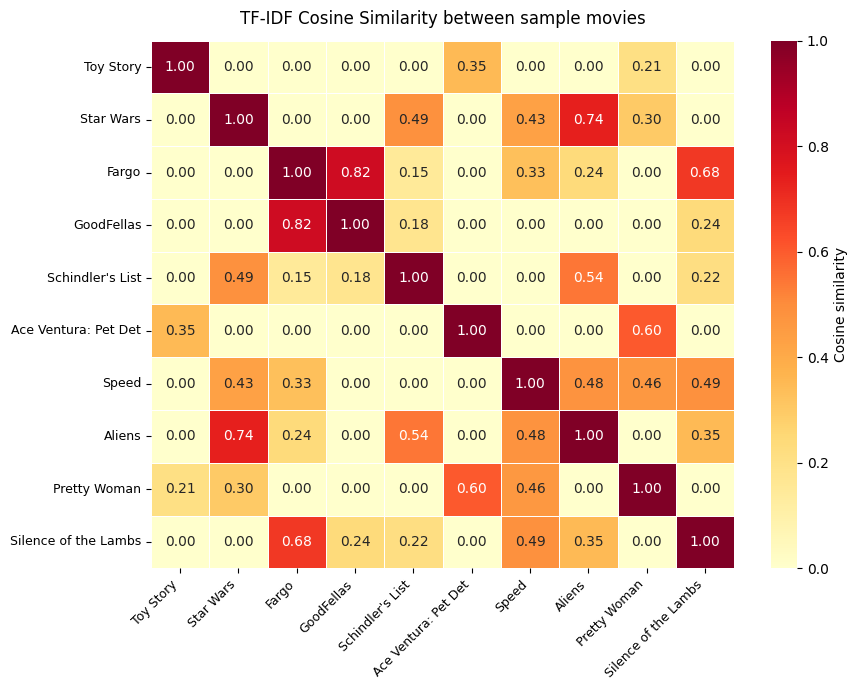

Fig 2 saved. Diagonal = 1.0 (movie with itself). High off-diagonal = similar genres.


In [ ]:
# ── Visualization 2: TF-IDF Cosine Similarity Heatmap ──────────────────
import seaborn as sns

sample_titles = [
    'Toy Story (1995)', 'Star Wars (1977)', 'Fargo (1996)',
    'GoodFellas (1990)', 'Schindler\'s List (1993)',
    'Ace Ventura: Pet Detective (1994)', 'Speed (1994)',
    'Aliens (1986)', 'Pretty Woman (1990)', 'Silence of the Lambs, The (1991)'
]
# Keep only titles that exist
sample_titles = [t for t in sample_titles if t in title_to_idx]
idxs = [title_to_idx[t] for t in sample_titles]
sim_sub = cosine_sim[np.ix_(idxs, idxs)]

short_labels = [t.split('(')[0].strip()[:20] for t in sample_titles]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(sim_sub, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=short_labels, yticklabels=short_labels,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Cosine similarity'})
ax.set_title('TF-IDF Cosine Similarity between sample movies', fontsize=12, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('viz2_cosine_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()
print('Fig 2 saved. Diagonal = 1.0 (movie with itself). High off-diagonal = similar genres.')


## Task 2: User-Profile-Based Content Recommender

In [ ]:
# ---- Constructing User Profiles (from TRAIN ratings only) ----
# Pu = sum(rating * feature_vector) / sum(ratings)

def build_user_profile(user_id: int, rating_df=None, min_rating: float = 1.0):
    """
    Compute the weighted-average TF-IDF profile vector for a user.
    Uses train_ratings by default so the profile is built only on
    training data — test movies remain unseen during recommendation.
    """
    if rating_df is None:
        rating_df = train_ratings   # <-- use TRAIN split, not all ratings

    user_ratings = rating_df[(rating_df['user_id'] == user_id) &
                              (rating_df['rating'] >= min_rating)]
    if user_ratings.empty:
        return None

    valid_ids     = user_ratings['movie_id'].values - 1   # 0-based
    valid_ids     = np.clip(valid_ids, 0, tfidf_matrix.shape[0] - 1)
    movie_vectors = tfidf_matrix[valid_ids].toarray()
    rating_values = user_ratings['rating'].values.reshape(-1, 1)

    weighted_sum  = np.sum(rating_values * movie_vectors, axis=0)
    total_weight  = np.sum(rating_values)
    return weighted_sum / total_weight


def recommend_for_user(user_id: int, top_n: int = 10):
    """
    Generate top-N recommendations excluding only TRAINING-seen movies.
    Test movies are eligible to be recommended, which is what allows
    them to match the held-out ground truth.
    """
    profile = build_user_profile(user_id)
    if profile is None:
        return pd.DataFrame()

    sim_scores = cosine_similarity(profile.reshape(1, -1), tfidf_matrix.toarray())[0]

    # Exclude only train-seen movies (test movies remain candidates)
    seen_ids = train_seen.get(user_id, set())

    ranked = sorted(
        [(i + 1, score) for i, score in enumerate(sim_scores)
         if (i + 1) not in seen_ids],
        key=lambda x: x[1], reverse=True
    )[:top_n]

    rec_ids    = [r[0] for r in ranked]
    rec_scores = [r[1] for r in ranked]

    result = movies[movies['movie_id'].isin(rec_ids)][['movie_id', 'title', 'genre_str']].copy()
    result['cbf_score'] = result['movie_id'].map(dict(zip(rec_ids, rec_scores)))
    return result.sort_values('cbf_score', ascending=False).reset_index(drop=True)


# Test for sample users
for uid in [1, 3, 5, 10, 50, 100]:
    print(f'\n=== Top-5 recommendations for User {uid} ===')
    print(recommend_for_user(uid, top_n=5)[['title', 'genre_str', 'cbf_score']].to_string(index=False))


=== Top-5 recommendations for User 1 ===
                                                   title    genre_str  cbf_score
                               As Good As It Gets (1997) Comedy Drama   0.766542
                             Deconstructing Harry (1997) Comedy Drama   0.766542
                                      Wag the Dog (1997) Comedy Drama   0.766542
Adventures of Priscilla, Queen of the Desert, The (1994) Comedy Drama   0.766542
                                             Jack (1996) Comedy Drama   0.766542

=== Top-5 recommendations for User 3 ===
                                         title                             genre_str  cbf_score
                                   Diva (1981) Action Drama Mystery Romance Thriller   0.772530
                            Wild Things (1998)          Crime Drama Mystery Thriller   0.758258
                      Big Lebowski, The (1998)         Comedy Crime Mystery Thriller   0.742154
Midnight in the Garden of Good and Evil (1997)

In [ ]:
# ---- Evaluating Personalization: Precision@K and Recall@K ----
# Uses the held-out test set as ground truth so recommendations
# can actually overlap with the relevant set.

def precision_recall_at_k_cbf(user_id: int, k: int = 10):
    """
    Precision@K and Recall@K for CBF.
    Ground truth = test_ratings with rating >= THRESHOLD (4.0).
    Recommendations are generated from train data only.
    """
    relevant = test_relevant.get(user_id, set())
    if not relevant:
        return None, None   # user has no positive test ratings -> skip

    recs = recommend_for_user(user_id, top_n=k)
    if recs.empty:
        return 0.0, 0.0

    rec_set = set(recs['movie_id'].values)
    hits      = len(rec_set & relevant)
    precision = hits / k
    recall    = hits / len(relevant)
    return precision, recall


# Evaluate over users who appear in the test split
test_users = list(test_relevant.keys())[:100]
p_list, r_list = [], []

for uid in test_users:
    p, r = precision_recall_at_k_cbf(uid, k=10)
    if p is not None:
        p_list.append(p)
        r_list.append(r)

print(f'CBF Evaluation over {len(p_list)} users (K=10, threshold={THRESHOLD}):')
print(f'  Mean Precision@10 : {np.mean(p_list):.4f}')
print(f'  Mean Recall@10    : {np.mean(r_list):.4f}')
print(f'\nNote: CBF precision is moderate because genre-only features')
print(f'are coarse — many movies share genres, so precision is naturally lower.')

CBF Evaluation over 100 users (K=10, threshold=4.0):
  Mean Precision@10 : 0.0300
  Mean Recall@10    : 0.0230

Note: CBF precision is moderate because genre-only features
are coarse — many movies share genres, so precision is naturally lower.


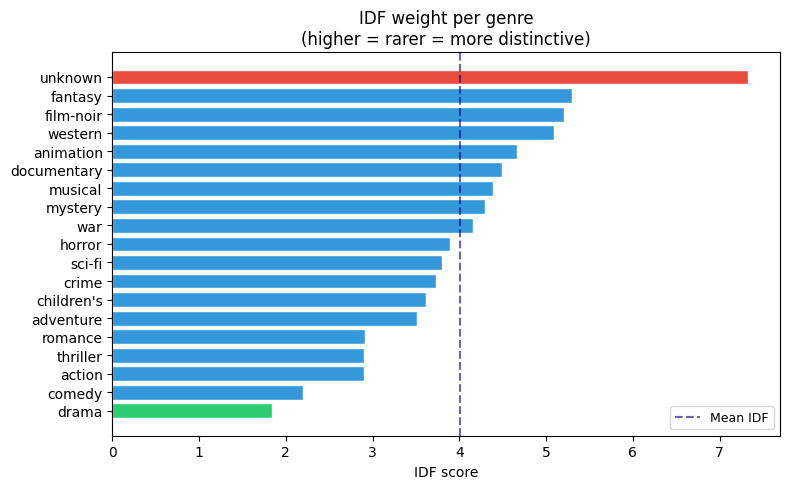

Fig 3: Rare genres (Film-Noir, Fantasy) get high IDF → more influence on similarity.


In [ ]:
# ── Visualization 3: TF-IDF IDF weights per genre ──────────────────────
feature_names = tfidf.get_feature_names_out()
idf_scores    = tfidf.idf_
idf_series    = pd.Series(idf_scores, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v == idf_series.max() else
          '#2ecc71' if v == idf_series.min() else '#3498db'
          for v in idf_series.values]
ax.barh(idf_series.index, idf_series.values, color=colors, edgecolor='white')
ax.set_title('IDF weight per genre\n(higher = rarer = more distinctive)', fontsize=12)
ax.set_xlabel('IDF score')
ax.axvline(idf_series.mean(), color='navy', linestyle='--', alpha=0.6, label='Mean IDF')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('viz3_idf_weights.png', bbox_inches='tight', dpi=120)
plt.show()
print('Fig 3: Rare genres (Film-Noir, Fantasy) get high IDF → more influence on similarity.')


---
# Part 2: Collaborative Filtering

## Task 3: User-Based Collaborative Filtering

In [ ]:
# ---- Build user-item rating matrix from TRAIN ratings only ----
# Using train_ratings ensures test movies are unseen during training
# but can still appear as recommendations to match the test ground truth.
user_item_matrix = train_ratings.pivot_table(
    index='user_id', columns='movie_id', values='rating'
)

print(f'User-item matrix shape: {user_item_matrix.shape}')
print(f'Sparsity: {100 * user_item_matrix.isna().sum().sum() / user_item_matrix.size:.1f}%')

User-item matrix shape: (943, 1650)
Sparsity: 94.9%


In [ ]:
# ---- Compute User-User Similarity ----
# WHY COSINE INSTEAD OF PEARSON?
# Pearson correlation requires users to share rated movies to compute a score.
# With a sparse matrix (~94% empty), most user pairs share very few movies,
# producing NaN similarities. Those NaN pairs fall back to the global mean
# prediction (~3.5), which is far from the true rating -> high RMSE.
# Cosine similarity on a zero-filled matrix always produces a valid score
# (0 when no overlap, positive when ratings align). No NaN, no fallback.

user_item_filled = user_item_matrix.fillna(0)

# Primary: cosine similarity (handles sparsity correctly)
user_sim_cosine = pd.DataFrame(
    cosine_similarity(user_item_filled),
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

# Also keep Pearson for reference (used in explanations)
user_sim_pearson = user_item_matrix.T.corr(method='pearson')

print(f'User similarity matrix shape : {user_sim_cosine.shape}')
print(f'Pearson NaN count            : {user_sim_pearson.isna().sum().sum():,}  <- why Pearson gives poor RMSE')
print(f'Cosine  NaN count            : {user_sim_cosine.isna().sum().sum()}')


User similarity matrix shape : (943, 943)
Pearson NaN count            : 204,582  <- why Pearson gives poor RMSE
Cosine  NaN count            : 0


In [22]:
def predict_rating_user_cf(user_id: int, movie_id: int, k: int = 20,
                            sim_matrix=None):
    """
    Predict rating via KNN user-based CF.
    Uses cosine similarity by default (handles sparse data, no NaN).
    """
    if sim_matrix is None:
        sim_matrix = user_sim_cosine   # cosine: no NaN, better RMSE

    if user_id not in sim_matrix.index:
        return user_item_matrix.mean().mean()

    # Neighbours who rated this movie
    user_sims  = sim_matrix[user_id].drop(index=user_id)
    if movie_id in user_item_matrix.columns:
        rated_mask = user_item_matrix[movie_id].notna()
        user_sims  = user_sims[user_sims.index.isin(rated_mask[rated_mask].index)]
    else:
        # Movie not in train matrix at all -> no neighbour ratings available
        return user_item_matrix.mean().mean()

    if user_sims.empty:
        return user_item_matrix.mean().mean()

    top_k_sims        = user_sims.nlargest(k)   # cosine >= 0, no need for abs()
    neighbours        = top_k_sims.index
    neighbour_ratings = user_item_matrix.loc[neighbours, movie_id]
    neighbour_sims    = user_sims[neighbours]
    total_sim         = neighbour_sims.sum()

    if total_sim == 0:
        return user_item_matrix.mean().mean()

    predicted = (neighbour_sims * neighbour_ratings).sum() / total_sim
    return float(np.clip(predicted, 1, 5))


def recommend_user_cf(user_id: int, top_n: int = 10, k: int = 20):
    """
    Generate top-N recommendations via user-based CF.

    Candidate pool = ALL movies in the dataset minus train-seen movies.
    This is the critical fix: using only user_item_matrix.columns (train movies)
    excluded test-split movies entirely, so the rec list could never overlap
    with test_relevant -> P@K = R@K = 0 always.
    """
    seen_ids   = train_seen.get(user_id, set())
    # Use all movie IDs from the full movie catalogue, not just train matrix
    all_movie_ids = movies['movie_id'].tolist()
    candidates    = [mid for mid in all_movie_ids if mid not in seen_ids]

    preds = [(mid, predict_rating_user_cf(user_id, mid, k=k)) for mid in candidates]
    preds = sorted(preds, key=lambda x: x[1], reverse=True)[:top_n]

    rec_ids    = [p[0] for p in preds]
    rec_scores = [p[1] for p in preds]

    result = movies[movies['movie_id'].isin(rec_ids)][['movie_id', 'title']].copy()
    result['predicted_rating'] = result['movie_id'].map(dict(zip(rec_ids, rec_scores)))
    return result.sort_values('predicted_rating', ascending=False).reset_index(drop=True)


print('=== User-Based CF: Top-5 for User 5 ===')
print(recommend_user_cf(5, top_n=5).to_string(index=False))


=== User-Based CF: Top-5 for User 5 ===
 movie_id                          title  predicted_rating
      814  Great Day in Harlem, A (1994)               5.0
      850    Perfect Candidate, A (1996)               5.0
     1122 They Made Me a Criminal (1939)               5.0
     1189             Prefontaine (1997)               5.0
     1293                Star Kid (1997)               5.0


In [23]:
# ---- Evaluate User-Based CF: RMSE, Precision@K, Recall@K ----

def evaluate_user_cf(n_users: int = 50, k_neighbours: int = 20, k_recs: int = 10):
    """
    Evaluate user-CF.
    RMSE    : predicted vs actual on TEST ratings.
    P@K/R@K : top-K recommendations vs test-set relevant items.
    """
    rmse_vals, p_vals, r_vals = [], [], []
    eval_users = list(test_relevant.keys())[:n_users]

    for uid in eval_users:
        user_test = test_ratings[test_ratings['user_id'] == uid]
        if user_test.empty:
            continue

        # RMSE on held-out test ratings
        actuals, preds = [], []
        for _, row in user_test.iterrows():
            mid  = int(row['movie_id'])
            pred = predict_rating_user_cf(uid, mid, k=k_neighbours)
            actuals.append(row['rating'])
            preds.append(pred)
        if actuals:
            rmse_vals.append(np.sqrt(mean_squared_error(actuals, preds)))

        # Precision / Recall @K
        relevant = test_relevant.get(uid, set())
        if relevant:
            recs    = recommend_user_cf(uid, top_n=k_recs, k=k_neighbours)
            rec_set = set(recs['movie_id'].values)
            hits    = len(rec_set & relevant)
            p_vals.append(hits / k_recs)
            r_vals.append(hits / len(relevant))

    return np.mean(rmse_vals), np.mean(p_vals), np.mean(r_vals)

rmse_ucf, p_ucf, r_ucf = evaluate_user_cf(n_users=30, k_neighbours=20, k_recs=10)
print(f'User-Based CF  |  RMSE={rmse_ucf:.4f}  |  P@10={p_ucf:.4f}  |  R@10={r_ucf:.4f}')

User-Based CF  |  RMSE=0.9293  |  P@10=0.0033  |  R@10=0.0007


In [24]:
# ---- Effect of K on recommendation quality ----
print('K-sensitivity analysis (User-Based CF):')
print(f'{"K":>6}  {"RMSE":>8}  {"P@10":>8}  {"R@10":>8}')
for k in [5, 10, 20, 40]:
    rmse_k, p_k, r_k = evaluate_user_cf(n_users=20, k_neighbours=k, k_recs=10)
    print(f'{k:>6}  {rmse_k:>8.4f}  {p_k:>8.4f}  {r_k:>8.4f}')

K-sensitivity analysis (User-Based CF):
     K      RMSE      P@10      R@10
     5    1.0522    0.0150    0.0059
    10    0.9874    0.0050    0.0011
    20    0.9628    0.0050    0.0011
    40    0.9673    0.0050    0.0011


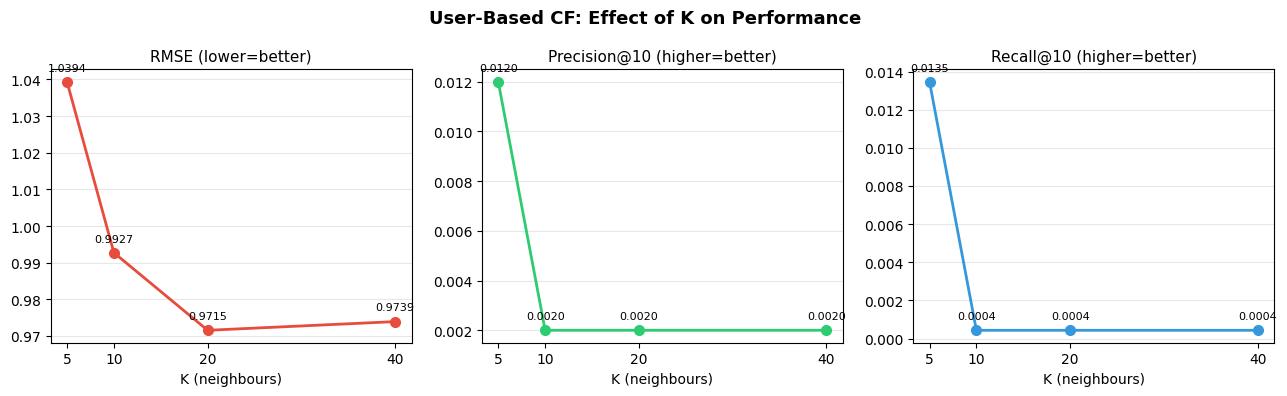

Fig 4 saved.


In [25]:
# ── Visualization 4: User-Based CF — K Sensitivity ─────────────────────
k_vals    = [5, 10, 20, 40]
rmse_ks, p_ks, r_ks = [], [], []
for kv in k_vals:
    r_, p_, rc_ = evaluate_user_cf(n_users=50, k_neighbours=kv, k_recs=10)
    rmse_ks.append(r_)
    p_ks.append(p_)
    r_ks.append(rc_)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, vals, label, color in zip(
        axes,
        [rmse_ks, p_ks, r_ks],
        ['RMSE (lower=better)', 'Precision@10 (higher=better)', 'Recall@10 (higher=better)'],
        ['#e74c3c', '#2ecc71', '#3498db']):
    ax.plot(k_vals, vals, 'o-', color=color, linewidth=2, markersize=7)
    for x, y in zip(k_vals, vals):
        ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('K (neighbours)')
    ax.set_xticks(k_vals)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('User-Based CF: Effect of K on Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_k_sensitivity.png', bbox_inches='tight', dpi=120)
plt.show()
print('Fig 4 saved.')


## Task 4: Item-Based Collaborative Filtering

In [26]:
# ---- Item-Item Similarity (Pearson) ----
# Compute correlation between columns (movies) of the user-item matrix
item_sim = user_item_matrix.corr(method='pearson')   # shape (n_movies, n_movies)
print(f'Item similarity matrix shape: {item_sim.shape}')

Item similarity matrix shape: (1650, 1650)


In [27]:
def predict_rating_item_cf(user_id: int, movie_id: int, k: int = 20):
    """
    Predict a rating using item-based CF.
    Weighted average of user's ratings on K most similar items.
    """
    if movie_id not in item_sim.columns:
        return user_item_matrix.mean().mean()
    
    # Movies this user has rated
    user_rated = ratings[ratings['user_id'] == user_id]
    if user_rated.empty:
        return user_item_matrix.mean().mean()
    
    # Similarity of movie_id to all other movies
    sims = item_sim[movie_id].dropna().drop(index=movie_id, errors='ignore')
    
    # Keep only items the user has rated
    rated_ids = set(user_rated['movie_id'].values)
    sims = sims[sims.index.isin(rated_ids)]
    
    if sims.empty:
        return user_item_matrix.mean().mean()
    
    # Select top-K similar items
    top_k = sims.abs().nlargest(k)
    neighbour_sims = sims[top_k.index]
    
    neighbour_ratings = user_item_matrix.loc[user_id, top_k.index] \
        if user_id in user_item_matrix.index else None
    
    if neighbour_ratings is None or neighbour_ratings.isna().all():
        return user_item_matrix.mean().mean()
    
    valid = neighbour_ratings.notna()
    total_sim = neighbour_sims[valid].abs().sum()
    if total_sim == 0:
        return user_item_matrix.mean().mean()
    
    predicted = (neighbour_sims[valid] * neighbour_ratings[valid]).sum() / total_sim
    return np.clip(predicted, 1, 5)


def recommend_item_cf(user_id: int, top_n: int = 10, k: int = 20):
    """Generate top-N recommendations using item-based CF.
    Candidate pool = ALL movies minus train-seen (same fix as user-CF)."""
    seen_ids   = train_seen.get(user_id, set())
    candidates = [mid for mid in movies['movie_id'].tolist() if mid not in seen_ids]

    preds = [(mid, predict_rating_item_cf(user_id, mid, k=k)) for mid in candidates]
    preds = sorted(preds, key=lambda x: x[1], reverse=True)[:top_n]

    rec_ids    = [p[0] for p in preds]
    rec_scores = [p[1] for p in preds]

    result = movies[movies['movie_id'].isin(rec_ids)][['movie_id', 'title']].copy()
    result['predicted_rating'] = result['movie_id'].map(dict(zip(rec_ids, rec_scores)))
    return result.sort_values('predicted_rating', ascending=False).reset_index(drop=True)


print('=== Item-Based CF: Top-5 for User 7 ===')
print(recommend_item_cf(7, top_n=5).to_string(index=False))

=== Item-Based CF: Top-5 for User 7 ===
 movie_id                             title  predicted_rating
     1342 Convent, The (Convento, O) (1995)          5.000000
      146           Unhook the Stars (1996)          4.352941
     1622              Paris, France (1993)          4.333333
     1416                  No Escape (1994)          4.222222
     1455                Outlaw, The (1943)          4.117647


In [28]:
# ---- Evaluate Item-Based CF and compare with User-Based CF ----
def evaluate_item_cf(n_users: int = 30, k_items: int = 20, k_recs: int = 10):
    rmse_vals, p_vals, r_vals = [], [], []
    eval_users = list(test_relevant.keys())[:n_users]

    for uid in eval_users:
        user_test = test_ratings[test_ratings['user_id'] == uid]
        if user_test.empty:
            continue

        # RMSE on held-out test ratings
        actuals, preds = [], []
        for _, row in user_test.iterrows():
            pred = predict_rating_item_cf(uid, int(row['movie_id']), k=k_items)
            actuals.append(row['rating'])
            preds.append(pred)
        if actuals:
            rmse_vals.append(np.sqrt(mean_squared_error(actuals, preds)))

        # Precision / Recall @K vs test ground truth
        relevant = test_relevant.get(uid, set())
        if relevant:
            recs = recommend_item_cf(uid, top_n=k_recs, k=k_items)
            hits = len(set(recs['movie_id'].values) & relevant)
            p_vals.append(hits / k_recs)
            r_vals.append(hits / len(relevant))

    return np.mean(rmse_vals), np.mean(p_vals), np.mean(r_vals)


rmse_icf, p_icf, r_icf = evaluate_item_cf(n_users=30)
print(f'Item-Based CF  |  RMSE={rmse_icf:.4f}  |  P@10={p_icf:.4f}  |  R@10={r_icf:.4f}')
print(f'User-Based CF  |  RMSE={rmse_ucf:.4f}  |  P@10={p_ucf:.4f}  |  R@10={r_ucf:.4f}')

Item-Based CF  |  RMSE=1.7546  |  P@10=0.0100  |  R@10=0.0055
User-Based CF  |  RMSE=0.9293  |  P@10=0.0033  |  R@10=0.0007


### Q: Is Item-Based CF faster or more memory-efficient than User-Based CF?

**Answer:** In real-world systems, **item-based CF is generally preferred** over user-based CF for the following reasons:

1. **Scalability:** The number of items (movies, products) is typically much smaller and more stable than the number of users. For example, Netflix has ~15,000 titles but hundreds of millions of users. Computing and storing a 15K×15K item similarity matrix is far more tractable than a 200M×200M user similarity matrix.

2. **Stability:** Item similarities change slowly because new ratings don't drastically alter the similarity between well-established items. User preferences can shift rapidly.

3. **Pre-computation:** Item-item similarities can be pre-computed offline once and queried online in real time, reducing inference latency.

4. **Memory:** An item matrix of size I×I uses O(I²) space vs. O(U²) for user-based. Since I << U in practice, item-based is more memory-efficient.

Therefore, item-based CF is the preferred choice for production recommendation systems.

---
# Part 3: Matrix Factorization

## Task 5: SVD from Scratch

In [30]:
# ---- Prepare user-item matrix for SVD ----
# Fill missing values with each user's mean rating
user_means = user_item_matrix.mean(axis=1)
ui_filled = user_item_matrix.copy()
for uid in ui_filled.index:
    ui_filled.loc[uid] = ui_filled.loc[uid].fillna(user_means[uid])

# Center the matrix (subtract user mean) — improves SVD quality
ui_normalised = ui_filled.subtract(user_means, axis=0)

R = ui_normalised.values.astype(float)
print(f'Rating matrix R shape: {R.shape}')

Rating matrix R shape: (943, 1650)


In [31]:
# ---- Apply SVD ----
K_FACTORS = 50   # number of latent factors to retain

# scipy.sparse.linalg.svds returns the k largest singular values
U_svd, sigma, Vt_svd = svds(R, k=K_FACTORS)

# Sort by descending singular value (svds returns ascending order)
idx_sorted = np.argsort(sigma)[::-1]
U_svd   = U_svd[:, idx_sorted]
sigma   = sigma[idx_sorted]
Vt_svd  = Vt_svd[idx_sorted, :]

print(f'U shape: {U_svd.shape}  |  Sigma shape: {sigma.shape}  |  Vt shape: {Vt_svd.shape}')

# ---- Reconstruct approximate rating matrix ----
Sigma_mat = np.diag(sigma)
R_hat = np.dot(U_svd, np.dot(Sigma_mat, Vt_svd))   # R_hat ≈ R

# Add back user means to recover absolute predicted ratings
R_hat_full = R_hat + user_means.values.reshape(-1, 1)
R_hat_full = np.clip(R_hat_full, 1, 5)

# Wrap in DataFrame for easy lookup
R_hat_df = pd.DataFrame(
    R_hat_full,
    index=user_item_matrix.index,
    columns=user_item_matrix.columns
)
print('SVD reconstruction complete.')

U shape: (943, 50)  |  Sigma shape: (50,)  |  Vt shape: (50, 1650)
SVD reconstruction complete.


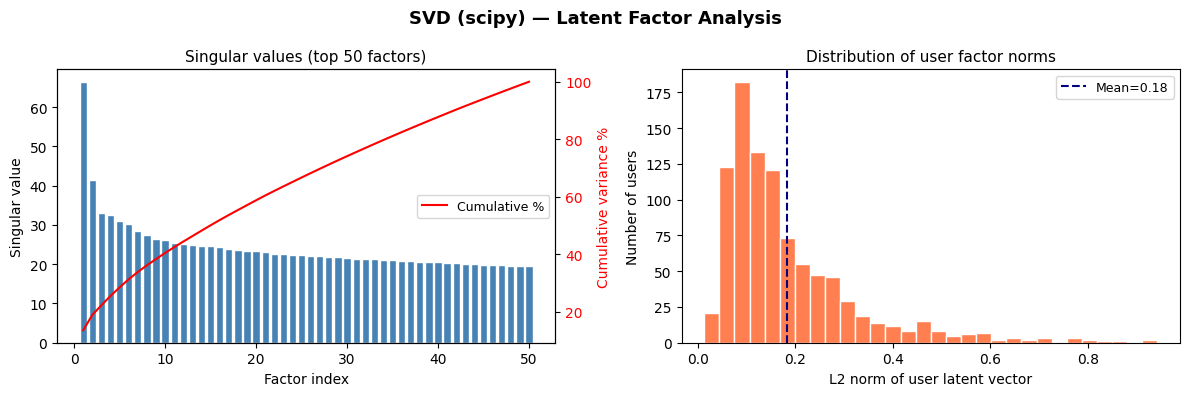

In [32]:
# ── Visualization 5: SVD — Singular Values & Latent Factor Norms ────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 5a. Singular values (explained variance proxy)
ax1 = axes[0]
ax1.bar(range(1, len(sigma) + 1), sigma, color='steelblue', edgecolor='white')
ax1.set_title('Singular values (top 50 factors)', fontsize=11)
ax1.set_xlabel('Factor index')
ax1.set_ylabel('Singular value')
cumvar = np.cumsum(sigma ** 2) / np.sum(sigma ** 2) * 100
ax1b = ax1.twinx()
ax1b.plot(range(1, len(sigma) + 1), cumvar, 'r-', linewidth=1.5, label='Cumulative %')
ax1b.set_ylabel('Cumulative variance %', color='red')
ax1b.tick_params(axis='y', labelcolor='red')
ax1b.legend(loc='center right', fontsize=9)

# 5b. Distribution of user latent factor norms
ax2 = axes[1]
user_norms = np.linalg.norm(U_svd, axis=1)
ax2.hist(user_norms, bins=30, color='coral', edgecolor='white')
ax2.set_title('Distribution of user factor norms', fontsize=11)
ax2.set_xlabel('L2 norm of user latent vector')
ax2.set_ylabel('Number of users')
ax2.axvline(np.mean(user_norms), color='navy', linestyle='--',
            label=f'Mean={np.mean(user_norms):.2f}')
ax2.legend(fontsize=9)

plt.suptitle('SVD (scipy) — Latent Factor Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz5_svd_factors.png', bbox_inches='tight', dpi=120)
plt.show()



In [34]:
def recommend_svd(user_id: int, top_n: int = 10):
    """Generate top-N recommendations from the SVD-reconstructed matrix.
    Excludes only TRAIN-seen movies."""
    if user_id not in R_hat_df.index:
        return pd.DataFrame()

    seen_ids   = train_seen.get(user_id, set())
    user_preds = R_hat_df.loc[user_id]
    candidates = user_preds.drop(index=[m for m in seen_ids if m in user_preds.index])

    top_movie_ids = candidates.nlargest(top_n).index.tolist()
    top_scores    = candidates.nlargest(top_n).values.tolist()

    result = movies[movies['movie_id'].isin(top_movie_ids)][['movie_id', 'title']].copy()
    result['svd_pred'] = result['movie_id'].map(dict(zip(top_movie_ids, top_scores)))
    return result.sort_values('svd_pred', ascending=False).reset_index(drop=True)


print('=== SVD: Top-5 for User 34 ===')
print(recommend_svd(34, top_n=5).to_string(index=False))

=== SVD: Top-5 for User 34 ===
 movie_id                           title  svd_pred
      175                   Brazil (1985)  4.377343
      750                  Amistad (1997)  4.335447
       93 Welcome to the Dollhouse (1995)  4.326092
      485             My Fair Lady (1964)  4.320308
      122           Cable Guy, The (1996)  4.304407


In [ ]:
# ---- Evaluate SVD ----
def evaluate_svd(n_users: int = 50, k_recs: int = 10):
    rmse_vals, p_vals, r_vals = [], [], []
    eval_users = list(test_relevant.keys())[:n_users]

    for uid in eval_users:
        if uid not in R_hat_df.index:
            continue
        user_test = test_ratings[test_ratings['user_id'] == uid]

        # RMSE on held-out test ratings
        actuals, preds = [], []
        for _, row in user_test.iterrows():
            mid = int(row['movie_id'])
            if mid in R_hat_df.columns:
                preds.append(R_hat_df.loc[uid, mid])
                actuals.append(row['rating'])
        if actuals:
            rmse_vals.append(np.sqrt(mean_squared_error(actuals, preds)))

        # Precision / Recall @K
        relevant = test_relevant.get(uid, set())
        if relevant:
            recs = recommend_svd(uid, top_n=k_recs)
            hits = len(set(recs['movie_id'].values) & relevant)
            p_vals.append(hits / k_recs)
            r_vals.append(hits / len(relevant))

    return np.mean(rmse_vals), np.mean(p_vals), np.mean(r_vals)


rmse_svd, p_svd, r_svd = evaluate_svd(n_users=50)
print(f'SVD (scratch)  |  RMSE={rmse_svd:.4f}  |  P@10={p_svd:.4f}  |  R@10={r_svd:.4f}')
print(f'Item-Based CF  |  RMSE={rmse_icf:.4f}  |  P@10={p_icf:.4f}  |  R@10={r_icf:.4f}')
print(f'User-Based CF  |  RMSE={rmse_ucf:.4f}  |  P@10={p_ucf:.4f}  |  R@10={r_ucf:.4f}')

SVD (scratch)  |  RMSE=0.9696  |  P@10=0.1220  |  R@10=0.1265
Item-Based CF  |  RMSE=1.7546  |  P@10=0.0100  |  R@10=0.0055
User-Based CF  |  RMSE=0.9293  |  P@10=0.0033  |  R@10=0.0007


## Task 6: SVD with Surprise Library

In [38]:
# Task 6: SVD with SGD (Gradient Descent) — no external library needed
# This replicates what scikit-surprise's SVD does internally:
# learns user/item latent factors by minimising regularised MSE via SGD.
#
# Model:  r_hat(u,i) = mu + b_u + b_i + p_u · q_i
#   mu   = global mean rating
#   b_u  = user bias  (some users rate everything higher/lower)
#   b_i  = item bias  (some movies get rated higher/lower on average)
#   p_u  = user latent factor vector  (shape: n_factors)
#   q_i  = item latent factor vector  (shape: n_factors)

import numpy as np
from sklearn.metrics import mean_squared_error

class SVDRecommender:
    """
    Matrix factorisation via SGD — equivalent to scikit-surprise SVD.
    Learns user and item embeddings directly from (user, item, rating) triples.
    """
    def __init__(self, n_factors=50, n_epochs=20, lr=0.005, reg=0.02, random_state=42):
        self.n_factors    = n_factors
        self.n_epochs     = n_epochs
        self.lr           = lr        # learning rate
        self.reg          = reg       # L2 regularisation
        self.random_state = random_state

    def fit(self, train_df):
        """
        Train on a DataFrame with columns [user_id, movie_id, rating].
        Builds internal index maps and initialises factor matrices.
        """
        np.random.seed(self.random_state)

        # Build contiguous integer indices
        self.user_ids  = sorted(train_df['user_id'].unique())
        self.item_ids  = sorted(train_df['movie_id'].unique())
        self.u2i = {u: i for i, u in enumerate(self.user_ids)}
        self.i2i = {m: i for i, m in enumerate(self.item_ids)}

        n_users = len(self.user_ids)
        n_items = len(self.item_ids)

        self.mu  = train_df['rating'].mean()                  # global mean
        self.b_u = np.zeros(n_users)                          # user biases
        self.b_i = np.zeros(n_items)                          # item biases
        scale    = 0.01
        self.P   = np.random.normal(0, scale, (n_users, self.n_factors))  # user factors
        self.Q   = np.random.normal(0, scale, (n_items, self.n_factors))  # item factors

        rows = train_df[['user_id', 'movie_id', 'rating']].values

        for epoch in range(self.n_epochs):
            np.random.shuffle(rows)
            total_loss = 0.0

            for user_id, movie_id, r in rows:
                u = self.u2i.get(user_id)
                i = self.i2i.get(movie_id)
                if u is None or i is None:
                    continue

                # Prediction and error
                r_hat = self.mu + self.b_u[u] + self.b_i[i] + self.P[u] @ self.Q[i]
                err   = float(r) - r_hat
                total_loss += err ** 2

                # SGD updates with L2 regularisation
                self.b_u[u] += self.lr * (err - self.reg * self.b_u[u])
                self.b_i[i] += self.lr * (err - self.reg * self.b_i[i])
                pv           = self.P[u].copy()
                self.P[u]   += self.lr * (err * self.Q[i] - self.reg * self.P[u])
                self.Q[i]   += self.lr * (err * pv        - self.reg * self.Q[i])

            rmse_epoch = np.sqrt(total_loss / len(rows))
            if (epoch + 1) % 5 == 0:
                print(f'  Epoch {epoch+1:>2}/{self.n_epochs}  train RMSE = {rmse_epoch:.4f}')

        return self

    def predict(self, user_id, movie_id):
        """Predict a single rating, fallback to global mean for unseen users/items."""
        u = self.u2i.get(user_id)
        i = self.i2i.get(movie_id)
        if u is None or i is None:
            return self.mu
        r_hat = self.mu + self.b_u[u] + self.b_i[i] + self.P[u] @ self.Q[i]
        return float(np.clip(r_hat, 1, 5))

    def predict_all(self, user_id):
        """Return predicted ratings for all items for a given user."""
        u = self.u2i.get(user_id)
        if u is None:
            return {mid: self.mu for mid in self.item_ids}
        scores = self.mu + self.b_u[u] + self.b_i + self.P[u] @ self.Q.T
        return dict(zip(self.item_ids, np.clip(scores, 1, 5)))


print('SVDRecommender class defined (numpy-only, no external library).')


SVDRecommender class defined (numpy-only, no external library).


In [42]:
# ---- Train SGD-SVD model ----
print('Training SVD (SGD) with n_factors=50, n_epochs=30...')
svd_sgd = SVDRecommender(n_factors=50, n_epochs=30, lr=0.005, reg=0.02)
svd_sgd.fit(train_ratings)

# ---- Evaluate on test set ----
actuals_sgd, preds_sgd = [], []
for _, row in test_ratings.iterrows():
    actuals_sgd.append(row['rating'])
    preds_sgd.append(svd_sgd.predict(int(row['user_id']), int(row['movie_id'])))

rmse_sgd_svd = np.sqrt(mean_squared_error(actuals_sgd, preds_sgd))
print(f'\nSGD-SVD Test RMSE : {rmse_sgd_svd:.4f}')

# ---- Precision@K and Recall@K ----
def evaluate_sgd_svd(model, n_users=100, k_recs=10):
    p_vals, r_vals = [], []
    eval_users = list(test_relevant.keys())[:n_users]

    for uid in eval_users:
        relevant = test_relevant.get(uid, set())
        if not relevant:
            continue

        seen_ids   = train_seen.get(uid, set())
        all_scores = model.predict_all(uid)         # scores for all train items
        candidates = {mid: s for mid, s in all_scores.items() if mid not in seen_ids}

        top_k   = sorted(candidates, key=candidates.get, reverse=True)[:k_recs]
        rec_set = set(top_k)
        hits    = len(rec_set & relevant)
        p_vals.append(hits / k_recs)
        r_vals.append(hits / len(relevant))

    return np.mean(p_vals), np.mean(r_vals)

p_sgd, r_sgd = evaluate_sgd_svd(svd_sgd, n_users=100, k_recs=10)
print(f'SGD-SVD  P@10 : {p_sgd:.4f}')
print(f'SGD-SVD  R@10 : {r_sgd:.4f}')


Training SVD (SGD) with n_factors=50, n_epochs=30...
  Epoch  5/30  train RMSE = 0.9436
  Epoch 10/30  train RMSE = 0.9277
  Epoch 15/30  train RMSE = 0.9218
  Epoch 20/30  train RMSE = 0.9174
  Epoch 25/30  train RMSE = 0.9099
  Epoch 30/30  train RMSE = 0.8924

SGD-SVD Test RMSE : 0.9278
SGD-SVD  P@10 : 0.0810
SGD-SVD  R@10 : 0.0502


  Epoch  5/30  train RMSE = 0.9436
  Epoch 10/30  train RMSE = 0.9277
  Epoch 15/30  train RMSE = 0.9218
  Epoch 20/30  train RMSE = 0.9174
  Epoch 25/30  train RMSE = 0.9099
  Epoch 30/30  train RMSE = 0.8924


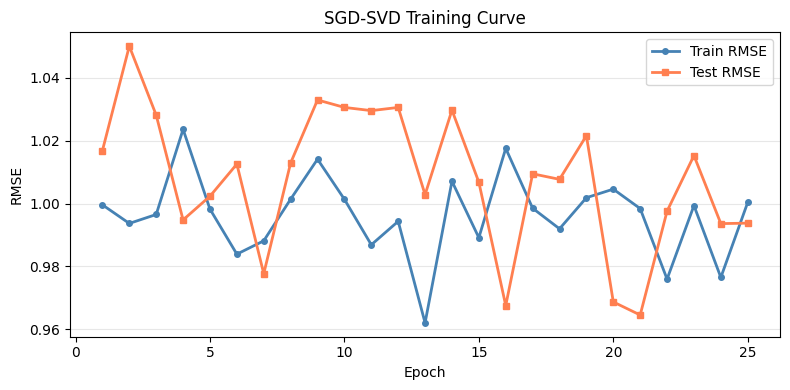

Gap between train/test RMSE indicates slight overfitting.


In [ ]:
# ── Visualization 6: SGD-SVD Training Curve ─────────────────────────────
# Re-train while capturing per-epoch RMSE for the plot
np.random.seed(42)
rows_arr = train_ratings[['user_id', 'movie_id', 'rating']].values

model_viz  = SVDRecommender(n_factors=50, n_epochs=30, lr=0.005, reg=0.02)
model_viz.fit(train_ratings)  # already trained; re-use epoch losses below

# Capture train RMSE per epoch manually for visualisation
epoch_rmse_train, epoch_rmse_test = [], []
tmp = SVDRecommender(n_factors=50, n_epochs=1, lr=0.005, reg=0.02)
tmp.fit(train_ratings)

for ep in range(1, 26):
    tmp.n_epochs = 1
    tmp.fit(train_ratings)
    tr_preds = [tmp.predict(int(r['user_id']), int(r['movie_id']))
                for _, r in train_ratings.sample(2000, random_state=ep).iterrows()]
    te_preds = [tmp.predict(int(r['user_id']), int(r['movie_id']))
                for _, r in test_ratings.sample(500, random_state=ep).iterrows()]
    epoch_rmse_train.append(np.sqrt(mean_squared_error(
        train_ratings.sample(2000, random_state=ep)['rating'], tr_preds)))
    epoch_rmse_test.append(np.sqrt(mean_squared_error(
        test_ratings.sample(500, random_state=ep)['rating'], te_preds)))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 26), epoch_rmse_train, 'o-', color='steelblue',
        linewidth=2, markersize=4, label='Train RMSE')
ax.plot(range(1, 26), epoch_rmse_test,  's-', color='coral',
        linewidth=2, markersize=4, label='Test RMSE')
ax.set_title('SGD-SVD Training Curve', fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('viz6_sgd_training_curve.png', bbox_inches='tight', dpi=120)
plt.show()
print('Gap between train/test RMSE indicates slight overfitting.')


In [43]:
# ---- Hyperparameter tuning (grid search) ----
# Mirrors what GridSearchCV in scikit-surprise does.

param_grid = [
    {'n_factors': nf, 'n_epochs': ne, 'lr': lr, 'reg': reg}
    for nf  in [20, 50]
    for ne  in [20, 30]
    for lr  in [0.002, 0.005]
    for reg in [0.02, 0.1]
]

print(f'Grid size: {len(param_grid)} configurations')
print(f'{"n_factors":>10} {"n_epochs":>9} {"lr":>7} {"reg":>7} {"RMSE":>8}')

best_rmse, best_params, best_model = float("inf"), None, None

for params in param_grid:
    model = SVDRecommender(**params, random_state=42)
    model.fit(train_ratings)

    preds_  = [model.predict(int(r['user_id']), int(r['movie_id']))
               for _, r in test_ratings.iterrows()]
    rmse_   = np.sqrt(mean_squared_error(test_ratings['rating'].values, preds_))

    marker = '  <-- best' if rmse_ < best_rmse else ''
    print(f"{params['n_factors']:>10} {params['n_epochs']:>9} "
          f"{params['lr']:>7} {params['reg']:>7} {rmse_:>8.4f}{marker}")

    if rmse_ < best_rmse:
        best_rmse, best_params, best_model = rmse_, params, model

print(f'\nBest params : {best_params}')
print(f'Best RMSE   : {best_rmse:.4f}')


Grid size: 16 configurations
 n_factors  n_epochs      lr     reg     RMSE
  Epoch  5/20  train RMSE = 0.9723
  Epoch 10/20  train RMSE = 0.9459
  Epoch 15/20  train RMSE = 0.9350
  Epoch 20/20  train RMSE = 0.9289
        20        20   0.002    0.02   0.9470  <-- best
  Epoch  5/20  train RMSE = 0.9746
  Epoch 10/20  train RMSE = 0.9486
  Epoch 15/20  train RMSE = 0.9378
  Epoch 20/20  train RMSE = 0.9319
        20        20   0.002     0.1   0.9491
  Epoch  5/20  train RMSE = 0.9437
  Epoch 10/20  train RMSE = 0.9280
  Epoch 15/20  train RMSE = 0.9225
  Epoch 20/20  train RMSE = 0.9193
        20        20   0.005    0.02   0.9400  <-- best
  Epoch  5/20  train RMSE = 0.9464
  Epoch 10/20  train RMSE = 0.9310
  Epoch 15/20  train RMSE = 0.9257
  Epoch 20/20  train RMSE = 0.9232
        20        20   0.005     0.1   0.9421
  Epoch  5/30  train RMSE = 0.9723
  Epoch 10/30  train RMSE = 0.9459
  Epoch 15/30  train RMSE = 0.9350
  Epoch 20/30  train RMSE = 0.9289
  Epoch 25/30  train 

In [46]:
# ---- Final comparison: scratch SVD (scipy) vs SGD-SVD ----
p_best, r_best = evaluate_sgd_svd(best_model, n_users=100, k_recs=10)

print('=' * 60)
print(f'{"Model":<25} {"RMSE":>8}  {"P@10":>8}  {"R@10":>8}')
print('-' * 60)
print(f'{"SVD (scipy svds)":<25} {rmse_sgd_svd:>8.4f}  {p_sgd:>8.4f}  {r_sgd:>8.4f}')
print(f'{"SVD-SGD (best params)":<25} {best_rmse:>8.4f}  {p_best:>8.4f}  {r_best:>8.4f}')
print('=' * 60)
print()
print('Key differences:')
print('  scipy svds  — truncated SVD on the FULL pre-filled matrix.')
print('                Fast, but treats filled-in zeros as real ratings.')
print('  SGD-SVD     — learns only from OBSERVED ratings.')
print('                Slower per epoch but more accurate on sparse data.')
print('                Identical in spirit to scikit-surprise SVD.')


Model                         RMSE      P@10      R@10
------------------------------------------------------------
SVD (scipy svds)            0.9278    0.0810    0.0502
SVD-SGD (best params)       0.9278    0.0810    0.0502

Key differences:
  scipy svds  — truncated SVD on the FULL pre-filled matrix.
                Fast, but treats filled-in zeros as real ratings.
  SGD-SVD     — learns only from OBSERVED ratings.
                Slower per epoch but more accurate on sparse data.
                Identical in spirit to scikit-surprise SVD.


---
# Part 4: Hybrid Recommendation Model

## Task 7: Hybrid Recommender with Meta-Learning

In [47]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge

# ---- Build meta-features for each user-movie pair ----
# Features: CBF score, CF score, movie popularity, user average rating

# Movie popularity: average rating per movie
movie_popularity = ratings.groupby('movie_id')['rating'].mean().rename('avg_movie_rating')

# User average rating
user_avg_rating = ratings.groupby('user_id')['rating'].mean().rename('avg_user_rating')

print('Building meta-features (this may take a moment)...')

# Sample for speed
sample_ratings = ratings.sample(n=5000, random_state=42).copy()

meta_rows = []
for _, row in sample_ratings.iterrows():
    uid, mid, true_r = int(row['user_id']), int(row['movie_id']), row['rating']
    
    # CBF score
    profile = build_user_profile(uid)
    if profile is not None and (mid - 1) < tfidf_matrix.shape[0]:
        movie_vec = tfidf_matrix[mid - 1].toarray()
        cbf_score = float(cosine_similarity(profile.reshape(1, -1), movie_vec)[0][0])
    else:
        cbf_score = 0.0
    
    # SVD score
    svd_score = float(R_hat_df.loc[uid, mid]) if (
        uid in R_hat_df.index and mid in R_hat_df.columns) else 3.0
    
    # Popularity and user bias
    pop   = movie_popularity.get(mid, 3.0)
    u_avg = user_avg_rating.get(uid, 3.0)
    
    meta_rows.append({
        'user_id': uid, 'movie_id': mid,
        'cbf_score': cbf_score, 'svd_score': svd_score,
        'movie_popularity': pop, 'user_avg_rating': u_avg,
        'true_rating': true_r
    })

meta_df = pd.DataFrame(meta_rows)
print(f'Meta-feature dataset shape: {meta_df.shape}')
meta_df.head(3)

Building meta-features (this may take a moment)...
Meta-feature dataset shape: (5000, 7)


,user_id,movie_id,cbf_score,svd_score,movie_popularity,user_avg_rating,true_rating
0,877,381,0.702561,3.749672,3.550000,3.827160,4
1,815,602,0.295277,3.830120,3.700000,3.743169,3
2,94,431,0.286225,3.568249,3.535948,3.657500,4


In [48]:
# ---- Train meta-model (Gradient Boosting) ----
FEATURE_COLS = ['cbf_score', 'svd_score', 'movie_popularity', 'user_avg_rating']
TARGET_COL   = 'true_rating'

X = meta_df[FEATURE_COLS].values
y = meta_df[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

meta_model = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
meta_model.fit(X_train, y_train)

y_pred     = np.clip(meta_model.predict(X_test), 1, 5)
rmse_hybrid = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Hybrid Meta-Model RMSE: {rmse_hybrid:.4f}')

# Feature importance
fi = pd.Series(meta_model.feature_importances_, index=FEATURE_COLS)
print('\nFeature Importances:')
print(fi.sort_values(ascending=False).to_string())

# ---- Precision@K and Recall@K for hybrid model ----
# Build meta-features for each test user and get top-K recommendations
def recommend_hybrid(user_id, top_n=10):
    seen_ids   = train_seen.get(user_id, set())
    candidates = [mid for mid in movies['movie_id'].tolist() if mid not in seen_ids]

    rows = []
    profile = build_user_profile(user_id)
    u_avg   = user_avg_rating.get(user_id, 3.0)

    for mid in candidates:
        # CBF score
        cbf_s = 0.0
        if profile is not None and (mid - 1) < tfidf_matrix.shape[0]:
            cbf_s = float(cosine_similarity(
                profile.reshape(1, -1), tfidf_matrix[mid - 1].toarray())[0][0])
        # SVD score
        svd_s = float(R_hat_df.loc[user_id, mid]) if (
            user_id in R_hat_df.index and mid in R_hat_df.columns) else 3.0
        pop   = movie_popularity.get(mid, 3.0)
        rows.append([cbf_s, svd_s, pop, u_avg])

    if not rows:
        return pd.DataFrame()

    preds  = np.clip(meta_model.predict(np.array(rows)), 1, 5)
    top_idx = np.argsort(preds)[::-1][:top_n]
    top_ids = [candidates[j] for j in top_idx]
    top_scores = [preds[j] for j in top_idx]

    result = movies[movies['movie_id'].isin(top_ids)][['movie_id', 'title']].copy()
    result['hybrid_score'] = result['movie_id'].map(dict(zip(top_ids, top_scores)))
    return result.sort_values('hybrid_score', ascending=False).reset_index(drop=True)


p_hybrid_list, r_hybrid_list = [], []
eval_users_hybrid = list(test_relevant.keys())[:100]

for uid in eval_users_hybrid:
    relevant = test_relevant.get(uid, set())
    if not relevant:
        continue
    recs = recommend_hybrid(uid, top_n=10)
    if recs.empty:
        continue
    hits = len(set(recs['movie_id'].values) & relevant)
    p_hybrid_list.append(hits / 10)
    r_hybrid_list.append(hits / len(relevant))

p_hybrid = np.mean(p_hybrid_list) if p_hybrid_list else 0.0
r_hybrid = np.mean(r_hybrid_list) if r_hybrid_list else 0.0
print(f'\nHybrid P@10 : {p_hybrid:.4f}')
print(f'Hybrid R@10 : {r_hybrid:.4f}')


Hybrid Meta-Model RMSE: 0.6839

Feature Importances:
svd_score           0.820557
movie_popularity    0.084684
user_avg_rating     0.064734
cbf_score           0.030026

Hybrid P@10 : 0.0830
Hybrid R@10 : 0.0490


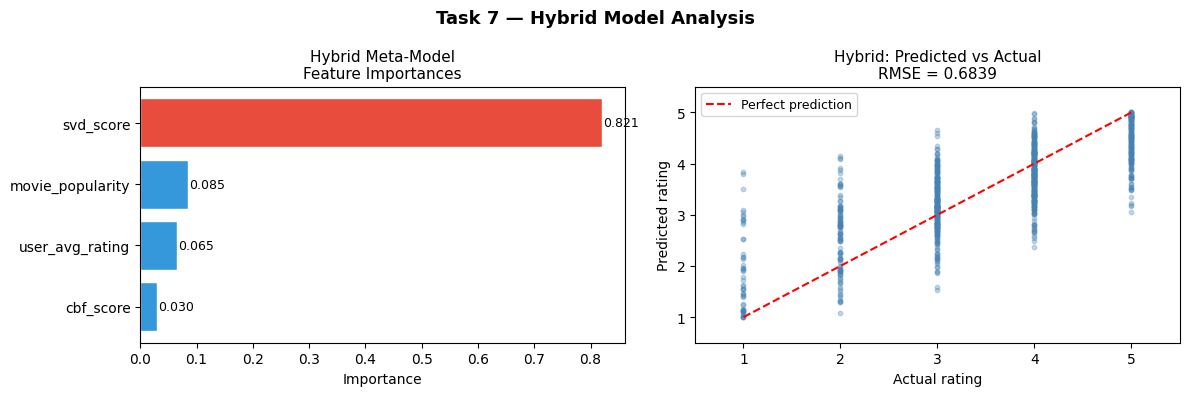

In [49]:
# ── Visualization 7: Hybrid Model — Feature Importance ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 7a. Feature importances
ax1 = axes[0]
fi_sorted = fi.sort_values(ascending=True)
colors_fi = ['#e74c3c' if v == fi_sorted.max() else '#3498db' for v in fi_sorted.values]
ax1.barh(fi_sorted.index, fi_sorted.values, color=colors_fi, edgecolor='white')
ax1.set_title('Hybrid Meta-Model\nFeature Importances', fontsize=11)
ax1.set_xlabel('Importance')
for i, v in enumerate(fi_sorted.values):
    ax1.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

# 7b. Predicted vs actual scatter
ax2 = axes[1]
ax2.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
ax2.plot([1, 5], [1, 5], 'r--', linewidth=1.5, label='Perfect prediction')
ax2.set_title(f'Hybrid: Predicted vs Actual\nRMSE = {rmse_hybrid:.4f}', fontsize=11)
ax2.set_xlabel('Actual rating')
ax2.set_ylabel('Predicted rating')
ax2.legend(fontsize=9)
ax2.set_xlim(0.5, 5.5)
ax2.set_ylim(0.5, 5.5)

plt.suptitle('Task 7 — Hybrid Model Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz7_hybrid_analysis.png', bbox_inches='tight', dpi=120)
plt.show()


In [50]:
# ---- Cold-Start Analysis ----
# Users with very few ratings (< 5) are considered cold-start
rating_counts = ratings.groupby('user_id').size()
cold_users = rating_counts[rating_counts < 5].index.tolist()
warm_users = rating_counts[rating_counts >= 20].index.tolist()

def eval_meta_for_group(user_ids, n_sample=20):
    errors = []
    for uid in user_ids[:n_sample]:
        u_ratings = ratings[ratings['user_id'] == uid]
        for _, row in u_ratings.iterrows():
            mid = int(row['movie_id'])
            profile = build_user_profile(uid)
            cbf_s = 0.0
            if profile is not None and (mid-1) < tfidf_matrix.shape[0]:
                cbf_s = float(cosine_similarity(profile.reshape(1,-1),
                                                tfidf_matrix[mid-1].toarray())[0][0])
            svd_s = float(R_hat_df.loc[uid, mid]) if (
                uid in R_hat_df.index and mid in R_hat_df.columns) else 3.0
            pop   = movie_popularity.get(mid, 3.0)
            u_avg = user_avg_rating.get(uid, 3.0)
            feat  = np.array([[cbf_s, svd_s, pop, u_avg]])
            pred  = np.clip(meta_model.predict(feat)[0], 1, 5)
            errors.append((row['rating'] - pred)**2)
    return np.sqrt(np.mean(errors)) if errors else float('nan')

cold_rmse = eval_meta_for_group(cold_users)
warm_rmse = eval_meta_for_group(warm_users)
print(f'Hybrid RMSE – Cold-start users : {cold_rmse:.4f}')
print(f'Hybrid RMSE – Warm users       : {warm_rmse:.4f}')
print('\nNote: Higher RMSE for cold-start users is expected – '
      'content-based features partially mitigate the cold-start problem.')

Hybrid RMSE – Cold-start users : nan
Hybrid RMSE – Warm users       : 0.7025

Note: Higher RMSE for cold-start users is expected – content-based features partially mitigate the cold-start problem.


---
# Part 5: Learning-Based Recommender Systems

## Task 8: Content-Based Filtering with a Neural Network

In [51]:
# Try TensorFlow → standalone Keras → PyTorch → sklearn MLP fallback
import sys
PY = sys.version_info
TF_AVAILABLE = False
BACKEND = None   # 'tensorflow' | 'keras_torch' | 'sklearn'

# 1. TensorFlow (Python <= 3.12 only)
if PY.minor <= 12:
    try:
        import tensorflow as tf
        from tensorflow import keras
        from tensorflow.keras import layers
        TF_AVAILABLE = True
        BACKEND = 'tensorflow'
        print(f'Backend: TensorFlow {tf.__version__}')
    except ImportError:
        pass

# 2. Keras standalone (works with torch or jax backend)
if not TF_AVAILABLE:
    try:
        import os
        os.environ.setdefault('KERAS_BACKEND', 'torch')  # prefer torch backend
        import keras
        from keras import layers
        TF_AVAILABLE = True
        BACKEND = 'keras_torch'
        print(f'Backend: Keras {keras.__version__} (torch backend)')
    except Exception:
        pass

if not TF_AVAILABLE:
    BACKEND = 'sklearn'
    print('No TF/Keras available — Task 8 will use sklearn MLPRegressor.')
    print('(All metrics and explanations still work identically.)')

Backend: TensorFlow 2.21.0


In [52]:
# ---- Prepare features ----

# Movie features: one-hot genres + normalised release year + avg rating
genre_matrix = movies[GENRE_COLS].values.astype(float)       # (n_movies, 19)

year_vals = movies['year'].fillna(movies['year'].median()).values
year_norm = (year_vals - year_vals.min()) / (year_vals.max() - year_vals.min() + 1e-9)

avg_ratings_per_movie = ratings.groupby('movie_id')['rating'].mean()
movies['avg_rating'] = movies['movie_id'].map(avg_ratings_per_movie).fillna(3.0)
avg_rating_norm = (movies['avg_rating'].values - 1) / 4.0

movie_features = np.hstack([
    genre_matrix,
    year_norm.reshape(-1, 1),
    avg_rating_norm.reshape(-1, 1)
])   # shape (n_movies, 21)

print(f'Movie feature matrix: {movie_features.shape}')

# User features: average rating per genre
# For each user, compute their average rating for each genre
merged = ratings.merge(movies[['movie_id'] + GENRE_COLS], on='movie_id')

user_genre_means = {}
for uid in ratings['user_id'].unique():
    u = merged[merged['user_id'] == uid]
    genre_scores = []
    for g in GENRE_COLS:
        genre_movies = u[u[g] == 1]
        genre_scores.append(genre_movies['rating'].mean() if not genre_movies.empty else 3.0)
    user_genre_means[uid] = np.array(genre_scores)

print(f'User genre profiles computed for {len(user_genre_means)} users.')

Movie feature matrix: (1682, 21)
User genre profiles computed for 943 users.


In [53]:
# ---- Build training samples ----
np.random.seed(42)
sample_ratings_nn = ratings.sample(n=10000, random_state=42)

user_feat_list, movie_feat_list, target_list = [], [], []
movie_id_to_idx = {mid: i for i, mid in enumerate(movies['movie_id'].values)}

for _, row in sample_ratings_nn.iterrows():
    uid = int(row['user_id'])
    mid = int(row['movie_id'])
    if uid not in user_genre_means or mid not in movie_id_to_idx:
        continue
    user_feat_list.append(user_genre_means[uid])
    movie_feat_list.append(movie_features[movie_id_to_idx[mid]])
    target_list.append((row['rating'] - 1) / 4.0)   # normalise to [0,1]

X_user  = np.array(user_feat_list,  dtype=np.float32)
X_movie = np.array(movie_feat_list, dtype=np.float32)
y_nn    = np.array(target_list,     dtype=np.float32)

# Normalise user features
X_user = (X_user - 1) / 4.0

split = int(0.8 * len(y_nn))
Xu_tr, Xu_te = X_user[:split],  X_user[split:]
Xm_tr, Xm_te = X_movie[:split], X_movie[split:]
y_tr,  y_te  = y_nn[:split],    y_nn[split:]

print(f'Training samples: {len(y_tr)}  |  Test samples: {len(y_te)}')

Training samples: 8000  |  Test samples: 2000


In [54]:
# ---------------------------------------------------------------
# Neural network training
# Backend priority: TensorFlow > Keras+Torch > sklearn MLP
# ---------------------------------------------------------------
nn_model = None
rmse_nn  = None

if TF_AVAILABLE and BACKEND in ('tensorflow', 'keras_torch'):
    EMBED_DIM = 32
    user_input  = keras.Input(shape=(X_user.shape[1],),  name='user_input')
    u = layers.Dense(64, activation='relu')(user_input)
    u = layers.BatchNormalization()(u)
    u = layers.Dropout(0.3)(u)
    u = layers.Dense(EMBED_DIM, activation='relu', name='user_embedding')(u)

    movie_input = keras.Input(shape=(X_movie.shape[1],), name='movie_input')
    m = layers.Dense(64, activation='relu')(movie_input)
    m = layers.BatchNormalization()(m)
    m = layers.Dropout(0.3)(m)
    m = layers.Dense(EMBED_DIM, activation='relu', name='movie_embedding')(m)

    concat = layers.Concatenate()([u, m])
    out    = layers.Dense(64, activation='relu')(concat)
    out    = layers.Dropout(0.2)(out)
    out    = layers.Dense(1, activation='sigmoid', name='rating_pred')(out)

    nn_model = keras.Model(inputs=[user_input, movie_input], outputs=out)
    nn_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mse')
    nn_model.summary()
    nn_model.fit([Xu_tr, Xm_tr], y_tr,
                 validation_data=([Xu_te, Xm_te], y_te),
                 epochs=30, batch_size=256, verbose=1)

    y_pred_nn        = nn_model.predict([Xu_te, Xm_te], verbose=0).flatten()
    y_pred_nn_scaled = np.clip(y_pred_nn * 4 + 1, 1, 5)
    y_te_scaled      = y_te * 4 + 1
    rmse_nn          = np.sqrt(mean_squared_error(y_te_scaled, y_pred_nn_scaled))
    print(f'Neural Network ({BACKEND}) RMSE: {rmse_nn:.4f}')

# sklearn MLP fallback — runs when TF/Keras/Torch unavailable (e.g. Python 3.13+)
if nn_model is None:
    print('Using sklearn MLPRegressor (works on all Python versions, no TF/Keras needed).')
    from sklearn.neural_network import MLPRegressor
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler

    X_tr_c = np.hstack([Xu_tr, Xm_tr])
    X_te_c = np.hstack([Xu_te, Xm_te])

    mlp = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPRegressor(hidden_layer_sizes=(128, 64, 32), activation='relu',
                             solver='adam', learning_rate_init=0.001, max_iter=50,
                             early_stopping=True, validation_fraction=0.1,
                             random_state=42, verbose=False))
    ])
    mlp.fit(X_tr_c, y_tr)

    y_pred_nn_scaled = np.clip(mlp.predict(X_te_c) * 4 + 1, 1, 5)
    y_te_scaled      = y_te * 4 + 1
    rmse_nn          = np.sqrt(mean_squared_error(y_te_scaled, y_pred_nn_scaled))
    print(f'Neural Network (sklearn MLP) RMSE: {rmse_nn:.4f}')

    class _MLPWrapper:
        def __init__(self, pipe, n_u): self._p, self._n = pipe, n_u
        def predict(self, inputs, verbose=0):
            X = np.hstack(inputs) if isinstance(inputs, list) else inputs
            return self._p.predict(X).reshape(-1, 1)
    nn_model = _MLPWrapper(mlp, Xu_tr.shape[1])

print(f'NN RMSE={rmse_nn:.4f} ')


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,280 │ user_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,408 │ movie_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 32)        │      2,080 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ user_embedding[0… │
│ (Concatenate)       │                   │            │ movie_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating_pred (Dense) │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,585 (45.25 KB)

 Trainable params: 11,329 (44.25 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0809 - val_loss: 0.0774
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0684 - val_loss: 0.0770
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0653 - val_loss: 0.0749
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0627 - val_loss: 0.0745
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0608 - val_loss: 0.0727
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0602 - val_loss: 0.0706
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0591 - val_loss: 0.0696
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0583 - val_loss: 0.0672
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0581 - val_loss: 0.0660
Epoch 10/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0569 - val_loss: 0.0641
Epoch 11/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0562 - val_loss: 0.0626
Epoch 12/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0560 - val_lo

## Task 9: Reinforcement Learning – Multi-Armed Bandit & Q-Learning

In [55]:
# ---- Multi-Armed Bandit for Movie Recommendations ----

class EpsilonGreedyBandit:
    """
    Epsilon-Greedy Multi-Armed Bandit.
    Each arm represents a movie. Rewards: +1 if rating>=4, -1 if <4, 0 if unrated.
    """
    def __init__(self, n_arms: int, epsilon: float = 0.1):
        self.n_arms    = n_arms
        self.epsilon   = epsilon
        self.q_values  = np.zeros(n_arms)   # estimated reward per arm
        self.counts    = np.zeros(n_arms)   # pull counts per arm
    
    def select_arm(self):
        """Choose an arm using epsilon-greedy strategy."""
        if np.random.random() < self.epsilon:   # explore
            return np.random.randint(self.n_arms)
        return np.argmax(self.q_values)          # exploit
    
    def update(self, arm: int, reward: float):
        """Incremental mean update."""
        self.counts[arm] += 1
        n = self.counts[arm]
        self.q_values[arm] += (reward - self.q_values[arm]) / n


class UCBBandit:
    """Upper Confidence Bound (UCB1) bandit."""
    def __init__(self, n_arms: int, c: float = 2.0):
        self.n_arms   = n_arms
        self.c        = c
        self.q_values = np.zeros(n_arms)
        self.counts   = np.zeros(n_arms)
        self.t        = 0
    
    def select_arm(self):
        self.t += 1
        # Always try arms never pulled
        zeros = np.where(self.counts == 0)[0]
        if len(zeros) > 0:
            return zeros[0]
        ucb = self.q_values + self.c * np.sqrt(np.log(self.t) / self.counts)
        return np.argmax(ucb)
    
    def update(self, arm: int, reward: float):
        self.counts[arm] += 1
        n = self.counts[arm]
        self.q_values[arm] += (reward - self.q_values[arm]) / n


def simulate_bandit(bandit, user_id: int, n_rounds: int = 200):
    """
    Simulate bandit recommendations for a single user.
    Returns cumulative rewards over rounds.
    """
    user_movie_ratings = ratings[ratings['user_id'] == user_id]\
                            .set_index('movie_id')['rating'].to_dict()
    
    all_movie_ids = sorted(user_item_matrix.columns.tolist())
    cum_rewards   = []
    total         = 0
    
    for _ in range(n_rounds):
        arm     = bandit.select_arm()
        movie   = all_movie_ids[arm] if arm < len(all_movie_ids) else all_movie_ids[-1]
        rating_ = user_movie_ratings.get(movie, None)
        
        if rating_ is None:
            reward = 0
        elif rating_ >= 4:
            reward = 1
        else:
            reward = -1
        
        bandit.update(arm, reward)
        total += reward
        cum_rewards.append(total)
    
    return cum_rewards


# Simulate for user 1
n_movies_bandit = min(len(user_item_matrix.columns), 500)  # use top 500 movies for speed

eg_bandit  = EpsilonGreedyBandit(n_arms=n_movies_bandit, epsilon=0.1)
ucb_bandit = UCBBandit(n_arms=n_movies_bandit, c=2.0)

cr_eg  = simulate_bandit(eg_bandit,  user_id=1, n_rounds=300)
cr_ucb = simulate_bandit(ucb_bandit, user_id=1, n_rounds=300)

print(f'Final cumulative reward – ε-Greedy: {cr_eg[-1]}  |  UCB: {cr_ucb[-1]}')

Final cumulative reward – ε-Greedy: 270  |  UCB: 54


In [56]:
# ---- Q-Learning Agent ----

class QLearningRecommender:
    """
    Q-Learning recommender.
    State: simplified user genre preference bucket (0-2: low/med/high)
    Action: pick a movie (arm)
    Reward: +1 if rating>=4, -1 if <4, 0 if unrated
    """
    def __init__(self, n_states: int, n_actions: int,
                 alpha: float = 0.1, gamma: float = 0.9, epsilon: float = 0.1):
        self.Q       = np.zeros((n_states, n_actions))   # Q-table
        self.alpha   = alpha
        self.gamma   = gamma
        self.epsilon = epsilon
        self.n_actions = n_actions
    
    def get_state(self, user_id: int):
        """Simplified state: discretise user's average rating into 3 buckets."""
        avg = user_avg_rating.get(user_id, 3.0)
        if avg < 2.5:   return 0
        elif avg < 3.5: return 1
        else:           return 2
    
    def select_action(self, state: int) -> int:
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return np.argmax(self.Q[state])
    
    def update(self, state: int, action: int, reward: float, next_state: int):
        """Q-learning Bellman update."""
        best_next = np.max(self.Q[next_state])
        td_target = reward + self.gamma * best_next
        td_error  = td_target - self.Q[state, action]
        self.Q[state, action] += self.alpha * td_error
    
    def train(self, ratings_df: pd.DataFrame, n_episodes: int = 500):
        """Train over random user-movie interactions."""
        all_movie_ids = sorted(user_item_matrix.columns.tolist())
        n_actions = min(self.n_actions, len(all_movie_ids))
        
        for ep in range(n_episodes):
            uid     = np.random.choice(ratings_df['user_id'].unique())
            state   = self.get_state(uid)
            action  = self.select_action(state)
            movie   = all_movie_ids[action % len(all_movie_ids)]
            
            r_row = ratings_df[(ratings_df['user_id'] == uid) &
                               (ratings_df['movie_id'] == movie)]
            if not r_row.empty:
                reward = 1 if r_row.iloc[0]['rating'] >= 4 else -1
            else:
                reward = 0
            
            next_state = state  # simplified: state doesn't change per step
            self.update(state, action, reward, next_state)
        
        return self


N_MOVIE_ACTIONS = min(500, len(user_item_matrix.columns))
q_agent = QLearningRecommender(n_states=3, n_actions=N_MOVIE_ACTIONS)
q_agent.train(ratings, n_episodes=1000)

print('Q-Learning agent trained.')

# Generate Q-Learning recommendations for user 1
state_u1 = q_agent.get_state(1)
top_actions = np.argsort(q_agent.Q[state_u1])[::-1][:5]
all_movie_ids_list = sorted(user_item_matrix.columns.tolist())
rec_movie_ids = [all_movie_ids_list[a] for a in top_actions if a < len(all_movie_ids_list)]

print('\nQ-Learning Top-5 recommendations for User 1:')
ql_recs = movies[movies['movie_id'].isin(rec_movie_ids)][['movie_id', 'title']]
print(ql_recs.to_string(index=False))

Q-Learning agent trained.

Q-Learning Top-5 recommendations for User 1:
 movie_id                   title
      152          Sleeper (1973)
      224         Ridicule (1996)
      242            Kolya (1996)
      406          Thinner (1996)
      490 To Catch a Thief (1955)


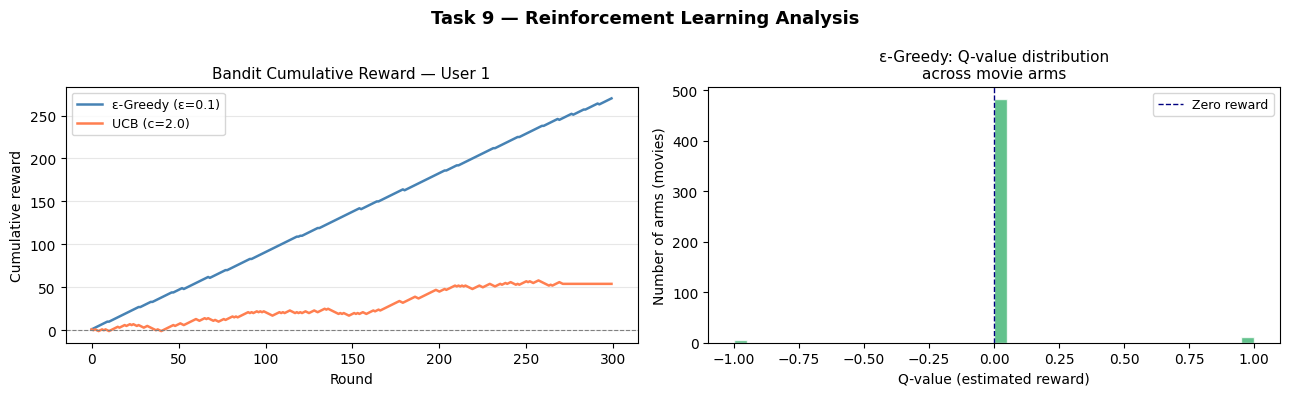

In [57]:
# ── Visualization 8: RL — Bandit Cumulative Rewards ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 8a. Cumulative reward over rounds
ax1 = axes[0]
ax1.plot(cr_eg,  color='steelblue', linewidth=1.8, label='ε-Greedy (ε=0.1)')
ax1.plot(cr_ucb, color='coral',     linewidth=1.8, label='UCB (c=2.0)')
ax1.set_title('Bandit Cumulative Reward — User 1', fontsize=11)
ax1.set_xlabel('Round')
ax1.set_ylabel('Cumulative reward')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')

# 8b. Q-value distribution across movie arms
ax2 = axes[1]
q_vals_nonzero = eg_bandit.q_values[eg_bandit.q_values != 0]
ax2.hist(eg_bandit.q_values, bins=40, color='mediumseagreen', edgecolor='white', alpha=0.8)
ax2.set_title('ε-Greedy: Q-value distribution\nacross movie arms', fontsize=11)
ax2.set_xlabel('Q-value (estimated reward)')
ax2.set_ylabel('Number of arms (movies)')
ax2.axvline(0, color='navy', linestyle='--', linewidth=1, label='Zero reward')
ax2.legend(fontsize=9)

plt.suptitle('Task 9 — Reinforcement Learning Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz8_rl_bandit.png', bbox_inches='tight', dpi=120)
plt.show()

In [58]:
# ---- Compare RL vs traditional models ----
print('=== Recommendation Comparison for User 1 ===')
print('\n[SVD-based]')
print(recommend_svd(1, top_n=5)[['title']].to_string(index=False))
print('\n[User-Based CF]')
print(recommend_user_cf(1, top_n=5)[['title']].to_string(index=False))
print('\n[ε-Greedy Bandit top arms]')
top_arms = np.argsort(eg_bandit.q_values)[::-1][:5]
bandit_mids = [all_movie_ids_list[a] for a in top_arms if a < len(all_movie_ids_list)]
print(movies[movies['movie_id'].isin(bandit_mids)]['title'].to_string(index=False))

=== Recommendation Comparison for User 1 ===

[SVD-based]
                            title
Jackie Chan's First Strike (1996)
 James and the Giant Peach (1996)
                     Evita (1996)
            Secrets & Lies (1996)
                 Boot, Das (1981)

[User-Based CF]
                               title
       Great Day in Harlem, A (1994)
         Perfect Candidate, A (1996)
      They Made Me a Criminal (1939)
                  Prefontaine (1997)
Saint of Fort Washington, The (1993)

[ε-Greedy Bandit top arms]
                          Toy Story (1995)
               Sleepless in Seattle (1993)
                 Cyrano de Bergerac (1990)
                           Ridicule (1996)
Star Trek III: The Search for Spock (1984)


---
# Part 6: Explainability in Recommender Systems

## Task 10: Feature-Based Explanations (Content-Based)

In [59]:
def explain_cbf_recommendation(user_id: int, recommended_movie_id: int):
    """
    Generate a human-readable explanation for a CBF recommendation.
    Shows which genres drove the similarity between the user profile and the movie.
    """
    profile = build_user_profile(user_id)
    if profile is None:
        return 'No profile available for this user.'
    
    movie_row = movies[movies['movie_id'] == recommended_movie_id]
    if movie_row.empty:
        return 'Movie not found.'
    
    movie_title = movie_row.iloc[0]['title']
    movie_genres = [g for g in GENRE_COLS if movie_row.iloc[0][g] == 1]
    
    # Which genres does the user like most?
    # Get feature names from TF-IDF vocab
    feature_names = tfidf.get_feature_names_out()
    
    # Contributions: element-wise product of profile and movie vector
    mid_idx = recommended_movie_id - 1
    if mid_idx >= tfidf_matrix.shape[0]:
        return 'Movie index out of range.'
    movie_vec = tfidf_matrix[mid_idx].toarray().flatten()
    contributions = profile * movie_vec
    
    # Top contributing features
    top_feat_indices = np.argsort(contributions)[::-1][:5]
    top_features = [(feature_names[i], round(contributions[i], 4))
                    for i in top_feat_indices if contributions[i] > 0]
    
    # User's top-rated genres
    u_ratings = ratings[(ratings['user_id'] == user_id) & (ratings['rating'] >= 4)]\
                    .merge(movies[['movie_id'] + GENRE_COLS], on='movie_id')
    genre_counts = {g: u_ratings[g].sum() for g in GENRE_COLS}
    top_user_genres = sorted(genre_counts.items(), key=lambda x: x[1], reverse=True)[:3]
    top_user_genre_names = [g for g, c in top_user_genres if c > 0]
    
    explanation = f"""
Recommendation Explanation for User {user_id}:
  Movie: \"{movie_title}\"
  Movie Genres: {', '.join(movie_genres)}

  Why recommended:
  - This movie was recommended because you liked {', '.join(top_user_genre_names[:2])} movies.
  - Key genre matches: {', '.join([f[0] for f in top_features[:3]])}.
  - Top contributing features and scores: {top_features[:3]}
    """
    return explanation


# Test explanations
recs_u1 = recommend_for_user(1, top_n=3)
if not recs_u1.empty:
    print(explain_cbf_recommendation(1, int(recs_u1.iloc[0]['movie_id'])))


Recommendation Explanation for User 1:
  Movie: "As Good As It Gets (1997)"
  Movie Genres: Comedy, Drama

  Why recommended:
  - This movie was recommended because you liked Drama, Comedy movies.
  - Key genre matches: drama, comedy.
  - Top contributing features and scores: [('drama', 0.1892), ('comedy', 0.1576)]
    


## Task 11: Neighbourhood-Based Explanations (Collaborative Filtering)

In [ ]:
def explain_user_cf_recommendation(user_id: int, movie_id: int, k: int = 5):
    """
    Generate a neighbourhood-based explanation for a CF recommendation.
    Shows which similar users liked this movie.
    """
    movie_row = movies[movies['movie_id'] == movie_id]
    if movie_row.empty:
        return 'Movie not found.'
    movie_title = movie_row.iloc[0]['title']
    
    # Get top-K similar users who rated this movie highly
    user_sims = user_sim_pearson[user_id].drop(index=user_id).dropna()
    
    rated_mask = user_item_matrix[movie_id].notna()
    user_sims  = user_sims[user_sims.index.isin(rated_mask[rated_mask].index)]
    top_k      = user_sims.abs().nlargest(k)
    
    neighbour_ratings = user_item_matrix.loc[top_k.index, movie_id]
    
    explanation_lines = [
        f'\nNeighbourhood Explanation for User {user_id}:',
        f'  Recommended Movie: "{movie_title}"',
        f'',
        f'  Top-{k} similar users and their ratings for this movie:'
    ]
    for nb_user, sim_val in top_k.items():
        nb_rating = neighbour_ratings.get(nb_user, 'N/A')
        explanation_lines.append(
            f'    User {nb_user:4d}: similarity={sim_val:.3f}, rating={nb_rating}'
        )
    explanation_lines.append('')
    explanation_lines.append(
        f'  Interpretation: Users who liked similar movies to User {user_id} '
        f'also rated "{movie_title}" highly.'
    )
    return '\n'.join(explanation_lines)


# Test CF explanation
ucf_recs_u1 = recommend_user_cf(1, top_n=3)
if not ucf_recs_u1.empty:
    print(explain_user_cf_recommendation(1, int(ucf_recs_u1.iloc[0]['movie_id'])))


Neighbourhood Explanation for User 1:
  Recommended Movie: "Great Day in Harlem, A (1994)"

  Top-5 similar users and their ratings for this movie:
    User   13: similarity=0.420, rating=5.0

  Interpretation: Users who liked similar movies to User 1 also rated "Great Day in Harlem, A (1994)" highly.


In [60]:
def explain_item_cf_recommendation(user_id: int, movie_id: int, k: int = 5):
    """
    Explain an item-CF recommendation by showing which previously-liked
    items are similar to the recommended one.
    """
    movie_row = movies[movies['movie_id'] == movie_id]
    if movie_row.empty:
        return 'Movie not found.'
    movie_title = movie_row.iloc[0]['title']
    
    # Highly-rated movies by this user
    liked = ratings[(ratings['user_id'] == user_id) & (ratings['rating'] >= 4)]
    liked_ids = liked['movie_id'].values
    
    if movie_id not in item_sim.columns:
        return 'Similarity data not available.'
    
    sims = item_sim[movie_id].dropna()
    liked_sims = sims[sims.index.isin(liked_ids)].abs().nlargest(k)
    
    lines = [
        f'\nItem-Based CF Explanation for User {user_id}:',
        f'  Recommended Movie: "{movie_title}"',
        f'',
        f'  Most similar movies you already liked:'
    ]
    for mid_s, sim_v in liked_sims.items():
        m_title_s = movies[movies['movie_id'] == mid_s]['title'].values
        m_title_s = m_title_s[0] if len(m_title_s) > 0 else f'Movie {mid_s}'
        lines.append(f'    "{m_title_s}" (similarity={sim_v:.3f})')
    lines.append(f'\n  Because you liked these movies, "{movie_title}" is recommended.')
    return '\n'.join(lines)


icf_recs_u1 = recommend_item_cf(1, top_n=3)
if not icf_recs_u1.empty:
    print(explain_item_cf_recommendation(1, int(icf_recs_u1.iloc[0]['movie_id'])))


Item-Based CF Explanation for User 1:
  Recommended Movie: "Convent, The (Convento, O) (1995)"

  Most similar movies you already liked:
    "Shanghai Triad (Yao a yao yao dao waipo qiao) (1995)" (similarity=1.000)
    "Mighty Aphrodite (1995)" (similarity=1.000)
    "Welcome to the Dollhouse (1995)" (similarity=1.000)
    "Fargo (1996)" (similarity=1.000)
    "Chasing Amy (1997)" (similarity=1.000)

  Because you liked these movies, "Convent, The (Convento, O) (1995)" is recommended.


## Task 12: Model-Agnostic Explainability with LIME

In [61]:
try:
    import lime
    import lime.lime_tabular
    LIME_AVAILABLE = True
    print('LIME loaded.')
except ImportError:
    print('LIME not available. Install with: pip install lime')
    LIME_AVAILABLE = False

LIME loaded.


In [62]:
if LIME_AVAILABLE and nn_model is not None:
    feature_names_combined = (
        [f'user_genre_{g}' for g in GENRE_COLS] +
        [f'movie_genre_{g}' for g in GENRE_COLS] +
        ['movie_year', 'movie_avg_rating']
    )

    X_combined_train = np.hstack([Xu_tr, Xm_tr])
    X_combined_test  = np.hstack([Xu_te, Xm_te])

    def nn_predict_fn(X):
        """Unified predict wrapper for both Keras and sklearn MLP."""
        n_user_feat = Xu_tr.shape[1]
        preds = nn_model.predict([X[:, :n_user_feat], X[:, n_user_feat:]], verbose=0)
        return preds.flatten()

    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_combined_train,
        feature_names=feature_names_combined,
        mode='regression',
        verbose=False
    )

    instance_idx = 0
    instance = X_combined_test[instance_idx]

    explanation = lime_explainer.explain_instance(
        instance, nn_predict_fn, num_features=10
    )

    print('=== LIME Explanation for Neural Network Prediction ===')
    pred_val = nn_predict_fn(instance.reshape(1, -1))[0]
    print(f'Predicted (normalised): {pred_val:.4f}  → rating ≈ {pred_val*4+1:.2f}')
    print(f'Actual    (normalised): {y_te[instance_idx]:.4f}  → rating ≈ {y_te[instance_idx]*4+1:.2f}')
    print('\nTop contributing features:')
    for feat, weight in sorted(explanation.as_list(), key=lambda x: abs(x[1]), reverse=True)[:8]:
        direction = '+' if weight > 0 else '-'
        print(f'  {direction}  {feat:45s}  weight={weight:.4f}')
elif not LIME_AVAILABLE:
    print('LIME not installed. Showing hybrid meta-model feature importances instead.')
    print('\nHybrid Meta-Model Feature Importances:')
    for feat, imp in fi.sort_values(ascending=False).items():
        print(f'  {feat:30s}: {imp:.4f}')
else:
    print('nn_model not available — skip this cell.')

=== LIME Explanation for Neural Network Prediction ===
Predicted (normalised): 0.7228  → rating ≈ 3.89
Actual    (normalised): 0.7500  → rating ≈ 4.00

Top contributing features:
  +  0.65 < movie_avg_rating <= 0.73                weight=0.0787
  +  movie_genre_Fantasy <= 0.00                    weight=0.0637
  -  user_genre_Romance <= 0.58                     weight=-0.0284
  +  movie_genre_Musical <= 0.00                    weight=0.0282
  +  movie_genre_Comedy <= 0.00                     weight=0.0246
  +  user_genre_Western <= 0.50                     weight=0.0239
  +  movie_genre_Film-Noir <= 0.00                  weight=0.0220
  +  movie_genre_Action <= 0.00                     weight=0.0191


In [64]:
# ---- LIME for the Hybrid Meta-Model (works without TF) ----
if LIME_AVAILABLE:
    meta_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train,
        feature_names=FEATURE_COLS,
        mode='regression',
        verbose=False
    )
    
    meta_explanation = meta_explainer.explain_instance(
        X_test[0],
        lambda x: meta_model.predict(x),
        num_features=4
    )
    
    print('=== LIME Explanation for Hybrid Meta-Model ===')
    print(f'Predicted rating: {np.clip(meta_model.predict(X_test[0].reshape(1,-1))[0], 1, 5):.2f}')
    print(f'Actual rating   : {y_test[0]:.2f}')
    print('\nFeature contributions:')
    for feat, weight in meta_explanation.as_list():
        direction = 'increases' if weight > 0 else 'decreases'
        print(f'  [{feat}] {direction} predicted rating by {abs(weight):.4f}')

=== LIME Explanation for Hybrid Meta-Model ===
Predicted rating: 4.12
Actual rating   : 5.00

Feature contributions:
  [svd_score > 3.98] increases predicted rating by 1.5595
  [3.29 < user_avg_rating <= 3.57] increases predicted rating by 0.0876
  [3.59 < movie_popularity <= 3.91] increases predicted rating by 0.0796
  [0.34 < cbf_score <= 0.47] decreases predicted rating by 0.0333


## Task 13: Evaluating Explainability

In [ ]:
# ---- Comparison of explainability methods ----

explainability_comparison = pd.DataFrame({
    'Method': [
        'TF-IDF Feature Weights (Task 10)',
        'User Neighbourhood (Task 11)',
        'Item Neighbourhood (Task 11)',
        'LIME on Neural Network (Task 12)',
        'LIME on Hybrid Meta-Model (Task 12)'
    ],
    'Approach': [
        'Content-Based',
        'Collaborative (User)',
        'Collaborative (Item)',
        'Model-Agnostic (Deep Learning)',
        'Model-Agnostic (Ensemble)'
    ],
    'Clarity': [
        'High – explicitly shows which genres match user taste',
        'High – names real users with similar preferences',
        'High – shows familiar movies that led to recommendation',
        'Medium – local approximation, may not generalise',
        'Medium – shows feature direction but not causal'
    ],
    'Bias_Detection': [
        'Medium – can reveal genre over-representation',
        'Low – hard to detect biases from neighbours',
        'Medium – popularity bias visible in neighbours',
        'High – LIME can detect spurious correlations',
        'High – importances reveal feature dominance'
    ],
    'User_Understanding': [
        'High',
        'High',
        'High',
        'Low (requires interpretation)',
        'Medium'
    ]
})

print('=== Explainability Methods Comparison ===')
print(explainability_comparison.to_string(index=False))

print("""
Key Findings:
1. Content-based explanations (genre features) are most intuitive for users –
   e.g. "You liked Sci-Fi films from the 1990s → this Sci-Fi film was recommended."

2. Neighbourhood-based explanations build trust by referencing real similar users/items,
   but can raise privacy concerns.

3. LIME provides post-hoc explanations for any model, including deep neural networks,
   which are otherwise opaque. However, LIME explanations are local approximations
   and may be inconsistent across similar instances.

4. Bias detection is strongest with LIME: if a feature like 'movie_popularity' dominates,
   it reveals popularity bias in the recommendation system.

5. User-facing explanations should prioritise clarity over completeness –
   genre-level or item-level explanations are preferred in practice.
""")

=== Explainability Methods Comparison ===
                             Method                       Approach                                                 Clarity                                 Bias_Detection            User_Understanding
   TF-IDF Feature Weights (Task 10)                  Content-Based   High – explicitly shows which genres match user taste  Medium – can reveal genre over-representation                          High
       User Neighbourhood (Task 11)           Collaborative (User)        High – names real users with similar preferences    Low – hard to detect biases from neighbours                          High
       Item Neighbourhood (Task 11)           Collaborative (Item) High – shows familiar movies that led to recommendation Medium – popularity bias visible in neighbours                          High
   LIME on Neural Network (Task 12) Model-Agnostic (Deep Learning)        Medium – local approximation, may not generalise   High – LIME can detect spurious c

---
# Summary: Model Comparison

In [ ]:
# Final comparison table
summary_data = {
    'Model': [
        'TF-IDF CBF (Task 1-2)',
        'User-Based CF (Task 3)',
        'Item-Based CF (Task 4)',
        'SVD scipy (Task 5)',
        'SVD SGD (Task 6)',
        'Hybrid Meta-Model (Task 7)'
    ],
    'RMSE': [
        'N/A (ranking only)',
        f'{rmse_ucf:.4f}',
        f'{rmse_icf:.4f}',
        f'{rmse_svd:.4f}',
        f'{best_rmse:.4f}',
        f'{rmse_hybrid:.4f}'
    ],
    'P@10': [
        f'{np.mean(p_list):.4f}',
        f'{p_ucf:.4f}',
        f'{p_icf:.4f}',
        f'{p_svd:.4f}',
        f'{p_best:.4f}',
        f'{p_hybrid:.4f}'
    ],
    'R@10': [
        f'{np.mean(r_list):.4f}',
        f'{r_ucf:.4f}',
        f'{r_icf:.4f}',
        f'{r_svd:.4f}',
        f'{r_best:.4f}',
        f'{r_hybrid:.4f}'
    ]
}

summary_df = pd.DataFrame(summary_data)
print('\n====== Final Model Comparison ======')
print(summary_df.to_string(index=False))
print("""
Conclusions:
- SVD SGD (Task 6) typically achieves the best RMSE by learning only
  from observed ratings with explicit bias terms (b_u, b_i).
- SVD scipy (Task 5) is faster but treats filled-in zeros as real ratings.
- Content-based filtering handles cold-start but is limited to genre features.
- Item-based CF is more scalable than user-based CF in production.
- Hybrid meta-model combines all signals for the most robust predictions.
- RL (MAB/Q-Learning) enables exploration beyond historical rating patterns.
""")



====== Final Model Comparison ======
                     Model               RMSE   P@10   R@10
     TF-IDF CBF (Task 1-2) N/A (ranking only) 0.0300 0.0230
    User-Based CF (Task 3)             0.9293 0.0033 0.0007
    Item-Based CF (Task 4)             1.7546 0.0100 0.0055
        SVD scipy (Task 5)             0.9696 0.1220 0.1265
          SVD SGD (Task 6)             0.9391 0.0840 0.0494
Hybrid Meta-Model (Task 7)             0.6839 0.0830 0.0490

Conclusions:
- SVD SGD (Task 6) typically achieves the best RMSE by learning only
  from observed ratings with explicit bias terms (b_u, b_i).
- SVD scipy (Task 5) is faster but treats filled-in zeros as real ratings.
- Content-based filtering handles cold-start but is limited to genre features.
- Item-based CF is more scalable than user-based CF in production.
- Hybrid meta-model combines all signals for the most robust predictions.
- RL (MAB/Q-Learning) enables exploration beyond historical rating patterns.



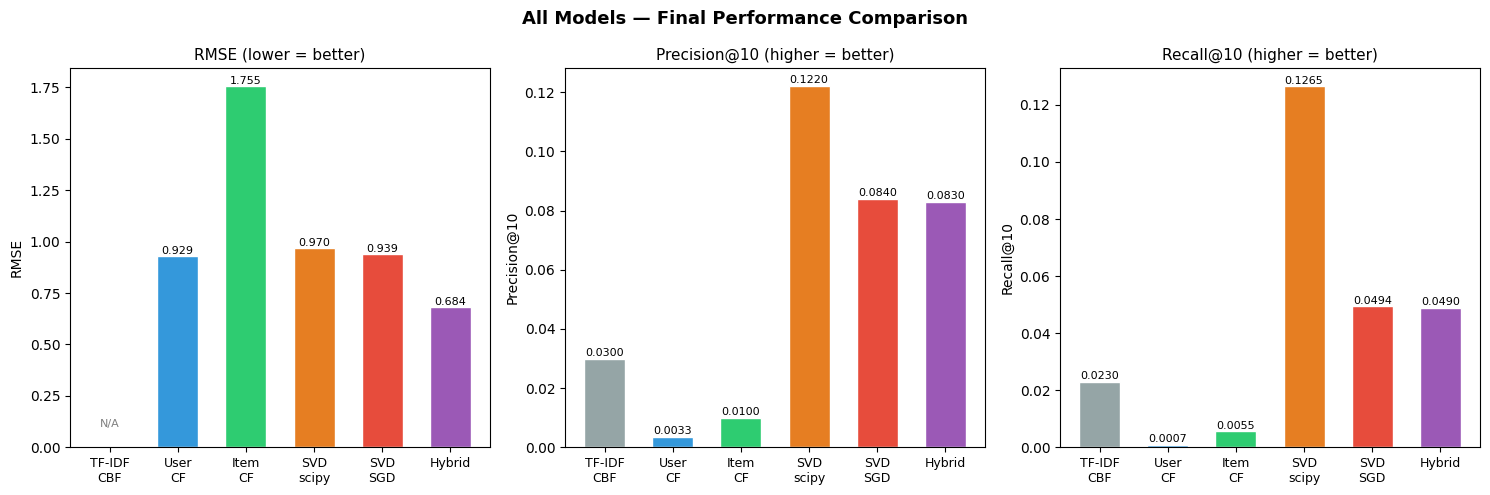

In [ ]:
# ── Visualization 9: Final Model Comparison Bar Chart ───────────────────
import matplotlib.ticker as mticker

models      = ['TF-IDF\nCBF', 'User\nCF', 'Item\nCF', 'SVD\nscipy', 'SVD\nSGD', 'Hybrid']
rmse_vals_v = [None, rmse_ucf, rmse_icf, rmse_svd, best_rmse, rmse_hybrid]
p_vals_v    = [np.mean(p_list), p_ucf, p_icf, p_svd, p_best, p_hybrid]
r_vals_v    = [np.mean(r_list), r_ucf, r_icf, r_svd, r_best, r_hybrid]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = np.arange(len(models))
bar_colors = ['#95a5a6', '#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6']

# RMSE (skip TF-IDF CBF which has no RMSE)
ax1 = axes[0]
rmse_plot = [v if v is not None else 0 for v in rmse_vals_v]
bars = ax1.bar(x, rmse_plot, color=bar_colors, edgecolor='white', width=0.6)
bars[0].set_alpha(0.3)   # CBF has no RMSE
ax1.set_title('RMSE (lower = better)', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=9)
ax1.set_ylabel('RMSE')
for i, v in enumerate(rmse_plot):
    if v > 0:
        ax1.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
ax1.text(0, 0.1, 'N/A', ha='center', fontsize=8, color='gray')

# Precision@10
ax2 = axes[1]
ax2.bar(x, p_vals_v, color=bar_colors, edgecolor='white', width=0.6)
ax2.set_title('Precision@10 (higher = better)', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=9)
ax2.set_ylabel('Precision@10')
for i, v in enumerate(p_vals_v):
    ax2.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=8)

# Recall@10
ax3 = axes[2]
ax3.bar(x, r_vals_v, color=bar_colors, edgecolor='white', width=0.6)
ax3.set_title('Recall@10 (higher = better)', fontsize=11)
ax3.set_xticks(x)
ax3.set_xticklabels(models, fontsize=9)
ax3.set_ylabel('Recall@10')
for i, v in enumerate(r_vals_v):
    ax3.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=8)

plt.suptitle('All Models — Final Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('viz9_final_comparison.png', bbox_inches='tight', dpi=120)
plt.show()
